# Auditoría de Calidad de Datos — NovaMarket

**Asignatura:** Preprocesamiento de datos · Semana 3

**Estudiante:** Ricardo Borja

**Trabajo de grupo 05:** María Andrea Torres, Ricardo Borja, Gabriel Murillo Velandia y Laura Marcela Gómez

**Fecha:** Agosto 04 de 2026

**Entregables:**  notebook (`S3_Grupo05_AuditoriaCalidad.ipynb`), el catálogo de problemas (`S3_Grupo05_CatalogoProblemas.xlsx`) e informe resumen (`S3_Grupo05_Informe_Auditoria_NovaMarket.pdf`)

**Revisión de consistencia.** Esta versión incorpora una revisión cruzada de todas las cifras del notebook contra el archivo de origen, la corrección del cruce con la fuente externa del DANE y la incorporación del código de los cruces de exactitud 5 a 8, que antes se citaban en el resumen sin quedar calculados en el documento.

## 1. Introducción

**Objetivo.** Realizar una auditoría de calidad sobre el dataset de ventas de NovaMarket, diagnosticando su estado en las seis dimensiones de calidad de datos (completitud, exactitud, consistencia, validez, unicidad y oportunidad), cuantificando cada problema encontrado con cifras y porcentajes.

Parte del diagnóstico se apoya en una **fuente externa oficial** para la dimensión de exactitud: la codificación DIVIPOLA del DANE, contra la cual se contrasta la coherencia entre `codigo_postal` y `ciudad_tienda`. El `codigo_postal` de esta versión trae **siete dígitos**, cuyos **cinco primeros corresponden al código de municipio DANE** y los dos últimos identifican la sede o zona; esa estructura es la que permite el cruce.

## Instalación librerias

In [1]:
!pip install pandas tabulate

## Importación librerias

In [2]:
import pandas as pd
import numpy as np
import unicodedata
import re

from IPython.display import display
import matplotlib.pyplot as plt

## Carga Base de Datos

In [3]:
ARCHIVO = "NovaMarket_datos_crudos.csv"

# Lectura normal: pandas convierte a NaN los vacios y sus centinelas por defecto.
df = pd.read_csv(ARCHIVO, low_memory=False)

# Lectura CRUDA en texto: conserva literalmente lo que hay en el archivo.
# Es la que permite auditar centinelas de vacio ("-", "sin dato", "N/A", ...)
# que pandas ya habria convertido silenciosamente a NaN en la lectura normal.
df_raw = pd.read_csv(ARCHIVO, dtype=str, keep_default_na=False, low_memory=False)

n = len(df)
print(f"Registros: {n:,}   Columnas: {df.shape[1]}")
df.info()

Registros: 640,000   Columnas: 20


<class 'pandas.DataFrame'>
RangeIndex: 640000 entries, 0 to 639999
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id_pedido                  640000 non-null  str    
 1   id_cliente                 640000 non-null  str    
 2   fecha_pedido               640000 non-null  str    
 3   canal_compra               640000 non-null  str    
 4   metodo_pago                640000 non-null  str    
 5   ciudad_tienda              610072 non-null  str    
 6   codigo_postal              640000 non-null  int64  
 7   categoria_producto         640000 non-null  str    
 8   producto                   640000 non-null  str    
 9   precio_unitario            618360 non-null  float64
 10  unidades_vendidas          640000 non-null  int64  
 11  monto_compra               618360 non-null  float64
 12  edad_cliente               640000 non-null  int64  
 13  correo_cliente             534688 non-nu

### Variables

Se identifican **20 variables** agrupadas por nivel de medición de la siguiente manera:

- **Nominales:** `id_pedido`, `id_cliente`, `canal_compra`, `metodo_pago`, `ciudad_tienda`, `categoria_producto`, `producto`, `correo_cliente`, `comentario_cliente`, `fuga_cliente`
- **Ordinales:** `nivel_satisfaccion` (Bajo < Medio < Alto), `nivel_lealtad` (Bronce < Plata < Oro < Platino), `codigo_postal` (código jerárquico: municipio DANE + sede)
- **Intervalo:** `fecha_pedido`, `fecha_actualizacion_stock`, `edad_cliente`
- **Razón:** `precio_unitario`, `unidades_vendidas`, `monto_compra`, `peso_pedido_kg`

Por tipo de dato leído: 13 columnas de texto, 4 numéricas enteras y 3 numéricas de punto flotante.

**Variables nuevas respecto de la versión anterior del dataset**

| Variable | Descripción | Papel en la auditoría |
|---|---|---|
| `metodo_pago` | Medio de pago del pedido (Efectivo, Tarjeta, PayPal, Transferencia) | Consistencia: presenta las mismas variantes de escritura que `canal_compra` |
| `monto_compra` | Valor total del pedido | Validez y exactitud: debe cumplir `monto_compra = precio_unitario × unidades_vendidas` |
| `nivel_lealtad` | Segmento del cliente (Bronce, Plata, Oro, Platino) | Consistencia y validez de dominio |
| `comentario_cliente` | Texto libre de la reseña | Completitud |
| `peso_pedido_kg` | Peso del pedido en kilogramos | Validez: rango plausible y outliers |
| `fuga_cliente` | Indicador binario de abandono (0/1) | Validez de dominio |

In [4]:
df.head()

,id_pedido,id_cliente,fecha_pedido,canal_compra,metodo_pago,ciudad_tienda,codigo_postal,categoria_producto,producto,precio_unitario,unidades_vendidas,monto_compra,edad_cliente,correo_cliente,nivel_satisfaccion,nivel_lealtad,comentario_cliente,peso_pedido_kg,fecha_actualizacion_stock,fuga_cliente
0,P505195,C45650,15/11/2025,Tienda,Efectivo,bogota,1100103,Moda,Chaqueta impermeable,28700.0,1,28700.0,32,cliente405195@novamarket.com.co,Bajo,Platino,El domiciliario fue muy amable,14.9,2026-04-17,0
1,P677836,C84260,2026-03-05,Web,Efectivo,MZL,1700101,Electrónica,Parlante bluetooth,195700.0,2,391400.0,73,cliente577836@yahoo.es,Medio,Bronce,El producto llegó dañado,12.9,2026-06-10,0
2,P387869,C164166,2025-03-13,Tienda,PayPal,Cúcuta,5400101,Juguetería,Rompecabezas 1000 piezas,597600.0,-3,-1792800.0,32,cliente287869@novamarket.com.co,Bajo,Oro,El domiciliario fue muy amable,14.3,2026-02-26,0
3,P481069,C98406,27/06/2025,App,transferencia,Cucuta,5400103,deportes,Colchoneta de yoga,322900.0,1,322900.0,45,cliente381069@gmail.com,Medio,Platino,Rápido y sin problemas,9.5,2026-05-14,0
4,P247920,C163018,01/05/2025,Web,Efectivo,Bucaramanga,6800112,Hogar,Juego de sábanas,222400.0,1,222400.0,60,cliente147920@novamarket.com.co,Alto,Plata,NaN,12.3,2026-07-13,0


In [5]:
df.describe(include='all')

,id_pedido,id_cliente,fecha_pedido,canal_compra,metodo_pago,ciudad_tienda,codigo_postal,categoria_producto,producto,precio_unitario,unidades_vendidas,monto_compra,edad_cliente,correo_cliente,nivel_satisfaccion,nivel_lealtad,comentario_cliente,peso_pedido_kg,fecha_actualizacion_stock,fuga_cliente
count,640000,640000,640000,640000,640000,610072,6.400000e+05,640000,640000,6.183600e+05,640000.000000,6.183600e+05,640000.000000,534688,593531,640000,549194,640000.000000,640000,640000.000000
unique,620000,152176,1775,20,20,88,NaN,32,24,NaN,NaN,NaN,NaN,518000,15,4,12,NaN,1177,NaN
top,P247920,C60642,00/00/0000,Marketplace,Transferencia,Villavicencio,NaN,Belleza,Parlante bluetooth,NaN,NaN,NaN,NaN,cliente147920@novamarket.com.co,Alto,Bronce,No era lo que esperaba,NaN,2026-05-07,NaN
freq,2,15,5698,121426,127962,27634,NaN,56378,27016,NaN,NaN,NaN,NaN,2,166739,160420,46107,NaN,3436,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,4.063765e+06,NaN,NaN,5.498868e+06,219.419042,1.281407e+09,48.818192,NaN,NaN,NaN,NaN,68.466064,NaN,0.209027
std,NaN,NaN,NaN,NaN,NaN,NaN,2.667342e+06,NaN,NaN,7.003612e+07,1330.372612,9.991062e+10,28.740425,NaN,NaN,NaN,NaN,250.219075,NaN,0.406614
min,NaN,NaN,NaN,NaN,NaN,NaN,5.001010e+05,NaN,NaN,-8.881000e+05,-3.000000,-8.580142e+09,-5.000000,NaN,NaN,NaN,NaN,8.000000,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.100170e+06,NaN,NaN,1.697000e+05,1.000000,2.226000e+05,31.000000,NaN,NaN,NaN,NaN,9.800000,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,4.700112e+06,NaN,NaN,3.056000e+05,1.000000,4.565000e+05,47.000000,NaN,NaN,NaN,NaN,11.700000,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,6.600192e+06,NaN,NaN,4.842000e+05,3.000000,8.568000e+05,62.000000,NaN,NaN,NaN,NaN,13.500000,NaN,0.000000


### Datos

Se confirman las mismas familias de problemas de la versión anterior, ahora a mayor escala: formatos de fecha distintos conviviendo en la misma columna, nombres de ciudad y categoría con el mismo significado escritos de formas diferentes (incluyendo abreviaturas tipo `BOG`, `MDE`, `CTG`), valores numéricos negativos en campos que no lo admiten y outliers imposibles. Se suman dos hallazgos propios de esta versión: **filas completamente duplicadas** (no solo el identificador repetido) y **`fecha_actualizacion_stock` anterior a la fecha del pedido**.

## 2. Diagnóstico por dimensión

### Funciones auxiliares

Se definen aquí, antes del diagnóstico, las funciones y constantes que se usan en varias dimensiones, para no repetirlas y para que el criterio sea idéntico en todas ellas.

In [6]:
FECHA_CORTE = pd.Timestamp("2026-08-04")   # fecha de corte de la auditoria

def base_texto(s):
    """Normaliza texto para comparar: minusculas, sin espacios extremos y sin tildes."""
    if pd.isna(s):
        return s
    s = str(s).strip().lower()
    return "".join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))

# Equivalencias que la normalizacion tipografica no puede resolver sola:
# abreviaturas de tres letras, nombres largos y contracciones.
EQUIV_CIUDAD = {
    "bogota d.c.": "bogota",   "bogota dc": "bogota",   "bogota, d.c.": "bogota",  "bog": "bogota",
    "b/quilla":    "barranquilla",  "baq": "barranquilla",
    "b/manga":     "bucaramanga",   "bga": "bucaramanga",
    "ctg":         "cartagena",     "cartagena de indias": "cartagena",
    "mde":         "medellin",      "medellin, ant.": "medellin",
    "mzl":         "manizales",     "manizales, caldas": "manizales",
    "smr":         "santa marta",   "sta. marta": "santa marta",  "santamarta": "santa marta",
    "clo":         "cali",          "santiago de cali": "cali",
}
EQUIV_CATEGORIA = {"juguetes": "jugueteria"}

def normalizar_ciudad(s):
    b = base_texto(s)
    return b if pd.isna(b) else EQUIV_CIUDAD.get(b, b)

def normalizar_categoria(s):
    b = base_texto(s)
    return b if pd.isna(b) else EQUIV_CATEGORIA.get(b, b)

def parsear_fechas(serie):
    """Parseo hibrido explicito: ISO estricto y luego dd/mm/aaaa estricto.
    Lo que no encaje en ninguno de los dos queda como NaT (formato invalido)."""
    s = serie.astype(str).str.strip()
    es_iso   = s.str.match(r"^\d{4}-\d{2}-\d{2}$")
    es_barra = s.str.match(r"^\d{1,2}/\d{1,2}/\d{4}$")
    iso   = pd.to_datetime(s.where(es_iso),   format="%Y-%m-%d", errors="coerce")
    barra = pd.to_datetime(s.where(es_barra), format="%d/%m/%Y", errors="coerce")
    return iso.fillna(barra)

# Fechas convertidas una sola vez, disponibles para validez y oportunidad
df["fecha_pedido_dt"] = parsear_fechas(df["fecha_pedido"])
df["fecha_stock_dt"]  = parsear_fechas(df["fecha_actualizacion_stock"])

print(f"Fecha de corte de la auditoria: {FECHA_CORTE.date()}")
print(f"fecha_pedido convertida: {df['fecha_pedido_dt'].notna().sum():,} validas, "
      f"{df['fecha_pedido_dt'].isna().sum():,} no parseables")
print(f"fecha_actualizacion_stock convertida: {df['fecha_stock_dt'].notna().sum():,} validas, "
      f"{df['fecha_stock_dt'].isna().sum():,} no parseables")

Fecha de corte de la auditoria: 2026-08-04
fecha_pedido convertida: 617,313 validas, 22,687 no parseables
fecha_actualizacion_stock convertida: 640,000 validas, 0 no parseables


### Completitud

**Replanteamiento de la medición.** Contar únicamente los `NaN` que reporta `isnull()` subestima el problema, puesto que un dato ausente puede estar registrado de varias maneras distintas en el archivo:

1. **celda realmente vacía** (`,,` en el CSV), que pandas lee como `NaN`;
2. **cadena vacía o solo espacios** (`" "`), que sobrevive como texto si no se limpia;
3. **centinelas textuales** que un humano escribió para decir «no hay dato»: `-`, `--`, `N/A`, `NA`, `ND`, `S/D`, `sin dato`, `desconocido`, `no aplica`, `ninguno`, `?`, `.`, `null`, `none`, `missing`;
4. **centinelas de fecha imposible** como `0000-00-00`.

El problema adicional es que **pandas ya convierte varios de esos tokens a `NaN` de forma silenciosa** al leer (`NA`, `N/A`, `null`, `none`, `nan`, `#N/A`, entre otros), por lo que trabajando solo sobre `df` es imposible saber si un faltante venía como celda vacía o como la palabra «NA» escrita a mano. Para poder distinguirlos se lee el archivo **dos veces**: una normal y otra en texto crudo con `keep_default_na=False`, y la auditoría se hace sobre la versión cruda.

La medida que se reporta es el **vacío efectivo**: la unión de los cuatro casos anteriores, calculada **para todas las columnas** y no solo para las que muestran `NaN`.

In [7]:
# Catalogo de centinelas de vacio a buscar (comparacion sobre el texto normalizado:
# recortado, en minusculas y sin tildes).
CENTINELAS = {
    "-", "--", "---", "_",
    "na", "n/a", "n.a.", "n.a", "nd", "n.d.", "s/d", "sd",
    "null", "none", "nan", "nil", "missing", "#n/a", "#na", "#valor!",
    "sin dato", "sin datos", "sin informacion", "sin info", "no informa",
    "desconocido", "no aplica", "no disponible", "ninguno", "ninguna",
    "vacio", "?", "??", ".", "..", "x", "xx", "n",
    "0000-00-00", "00/00/0000", "1900-01-01",
}
# Nota: "-1" NO se incluye. En columnas numericas es un valor de pleno derecho y aqui
# marcaria como "sin dato" las unidades negativas, que ya se cuentan en validez como
# violacion de dominio. Contarlas tambien como vacio seria medir dos veces el mismo error.

def texto_norm(serie):
    """Normaliza para comparar: quita espacios de los extremos, pasa a minusculas y elimina tildes."""
    s = serie.astype("string").str.strip().str.lower()
    return s.map(
        lambda v: v if pd.isna(v)
        else "".join(c for c in unicodedata.normalize("NFKD", v) if not unicodedata.combining(c))
    )

filas = []
centinelas_hallados = {}

for col in df_raw.columns:
    crudo = df_raw[col]              # texto literal del archivo
    norm  = texto_norm(crudo)

    nulos_pandas = int(df[col].isna().sum())        # lo que reporta la lectura normal
    vacia_literal = int((crudo == "").sum())        # celda realmente vacia en el archivo
    solo_espacios = int(((crudo != "") & (crudo.str.strip() == "")).sum())
    es_centinela  = norm.isin(CENTINELAS).fillna(False)
    n_centinela   = int(es_centinela.sum())

    # Que centinelas concretos aparecieron en esta columna (evidencia, no supuesto)
    if n_centinela:
        centinelas_hallados[col] = norm[es_centinela].value_counts().to_dict()

    # Vacio efectivo = celda vacia OR solo espacios OR centinela textual
    vacio_efectivo = int((
        (crudo == "") | ((crudo.str.strip() == "") & (crudo != "")) | es_centinela
    ).sum())

    filas.append({
        "Columna":              col,
        "NaN (lectura normal)": nulos_pandas,
        "Celda vacia":          vacia_literal,
        "Solo espacios":        solo_espacios,
        "Centinela textual":    n_centinela,
        "Vacio efectivo":       vacio_efectivo,
        "% vacio efectivo":     round(vacio_efectivo / n * 100, 2),
    })

tabla_completitud = (pd.DataFrame(filas)
                       .sort_values("Vacio efectivo", ascending=False)
                       .reset_index(drop=True))

display(tabla_completitud.style.hide(axis="index")
        .format({"% vacio efectivo": "{:.2f}%"}))

# El recuento se hace sobre las columnas del ARCHIVO (df_raw). Usar df.shape[1] aqui
# contaria de mas, porque a df ya se le agregaron las dos columnas de fecha convertida.
n_cols = df_raw.shape[1]
col_con_vacio = int((tabla_completitud["Vacio efectivo"] > 0).sum())
print(f"Columnas del archivo:              {n_cols}")
print(f"Columnas con algun vacio efectivo: {col_con_vacio} de {n_cols}")
print(f"Columnas completas (0 vacios):     {n_cols - col_con_vacio}")

Columna,NaN (lectura normal),Celda vacia,Solo espacios,Centinela textual,Vacio efectivo,% vacio efectivo
correo_cliente,105312,105312,0,0,105312,16.46%
comentario_cliente,90806,90806,0,0,90806,14.19%
nivel_satisfaccion,46469,46469,0,0,46469,7.26%
ciudad_tienda,29928,29928,0,0,29928,4.68%
monto_compra,21640,21640,0,0,21640,3.38%
precio_unitario,21640,21640,0,0,21640,3.38%
fecha_pedido,0,0,0,5698,5698,0.89%
id_pedido,0,0,0,0,0,0.00%
canal_compra,0,0,0,0,0,0.00%
id_cliente,0,0,0,0,0,0.00%


Columnas del archivo:              20
Columnas con algun vacio efectivo: 7 de 20
Columnas completas (0 vacios):     13


In [8]:
# Evidencia: que centinelas textuales se encontraron realmente y cuales se buscaron sin exito.
print(f"Se verificaron {len(CENTINELAS)} tokens distintos sobre las {df_raw.shape[1]} columnas del archivo.")
print()

if centinelas_hallados:
    print("Centinelas textuales ENCONTRADOS por columna:")
    for col, d in centinelas_hallados.items():
        for token, veces in d.items():
            print(f"  {col:28s} {token!r:14s} {veces:>7,} registros  ({veces/n*100:.2f}%)")
    print()
    print("El resto de columnas representa el dato ausente unicamente como celda vacia.")
else:
    print("No se encontro NINGUN centinela textual de la lista en el archivo:")
    print("el dato ausente se representa siempre como celda vacia.")

print()
print("Tokens buscados:")
print("  " + ", ".join(sorted(CENTINELAS)))

# Verificacion cruzada: el vacio efectivo nunca puede ser menor que los NaN reportados por pandas
assert (tabla_completitud["Vacio efectivo"] >= tabla_completitud["NaN (lectura normal)"]).all()
print()
print("Verificacion OK: vacio efectivo >= NaN en todas las columnas.")

Se verificaron 41 tokens distintos sobre las 20 columnas del archivo.

Centinelas textuales ENCONTRADOS por columna:
  fecha_pedido                 '00/00/0000'     5,698 registros  (0.89%)

El resto de columnas representa el dato ausente unicamente como celda vacia.

Tokens buscados:
  #n/a, #na, #valor!, -, --, ---, ., .., 00/00/0000, 0000-00-00, 1900-01-01, ?, ??, _, desconocido, missing, n, n.a, n.a., n.d., n/a, na, nan, nd, nil, ninguna, ninguno, no aplica, no disponible, no informa, none, null, s/d, sd, sin dato, sin datos, sin info, sin informacion, vacio, x, xx

Verificacion OK: vacio efectivo >= NaN en todas las columnas.


Los vacíos efectivos se distribuyen así:

| Columna | Vacíos | % del total | Nivel | Razón |
|---|---:|---:|---|---|
| `correo_cliente` | 105 312 | 16.46% | Bajo impacto | Es la de mayor volumen, pero no entra en promedios, sumas ni modelos; puede dejarse vacía o marcarse explícitamente como desconocida. |
| `comentario_cliente` | 90 806 | 14.19% | Bajo impacto | Texto libre opcional. Su ausencia es informativa en sí misma (el cliente no comentó) y no debería imputarse. |
| `nivel_satisfaccion` | 46 469 | 7.26% | Medio | Es variable de análisis: al faltar se pierde la observación en cualquier cruce de satisfacción, y su ausencia puede no ser aleatoria. |
| `ciudad_tienda` | 29 928 | 4.68% | Medio | Rompe la segmentación geográfica. Es recuperable a partir de `codigo_postal`, que está completo, lo cual la convierte en el faltante más barato de corregir. |
| `precio_unitario` | 21 640 | 3.38% | Medio | Entra en cálculos monetarios; imputarla con la media distorsiona los agregados de venta. |
| `monto_compra` | 21 640 | 3.38% | Medio | Faltan exactamente en las mismas filas que `precio_unitario`, porque el monto se deriva de él. |
| `fecha_pedido` | 5 698 | 0.89% | Medio | **Solo aparece con la lectura cruda.** Son celdas con el texto `00/00/0000`, que pandas cuenta como dato presente porque técnicamente hay contenido en la celda. |

Las 13 columnas restantes no presentan ningún vacío efectivo.

**Hallazgo del replanteamiento.** Este es el resultado que justifica haber cambiado la forma de medir. Contando solo `isnull()` la columna `fecha_pedido` aparece **completa al 100%**, puesto que sus 640 000 celdas tienen contenido. Al leer el archivo en texto crudo se ve que 5 698 de ellas dicen `00/00/0000`, que es un marcador de fecha ausente y no una fecha. Es decir, la medición anterior escondía 5 698 faltantes detrás de una columna aparentemente perfecta.

En el resto de columnas el resultado coincide con el conteo de `NaN`, pero ahora eso es una **conclusión verificada** y no un supuesto de partida: se contrastaron 41 tokens distintos y ninguna celda contiene solo espacios.

**Nota sobre `ciudad_tienda` y `codigo_postal`.** Ambas describen la misma sede, pero `codigo_postal` está completo al 100% mientras `ciudad_tienda` tiene 29 928 vacíos. Como los cinco primeros dígitos del código son el municipio DANE, esos vacíos pueden imputarse de forma determinista, sin recurrir a moda ni a ninguna estimación.

**Visualización del vacío efectivo por columna.** El gráfico ordena las columnas por proporción de vacío, haciendo visible de un vistazo dónde se concentra el problema que la tabla anterior cuantifica.

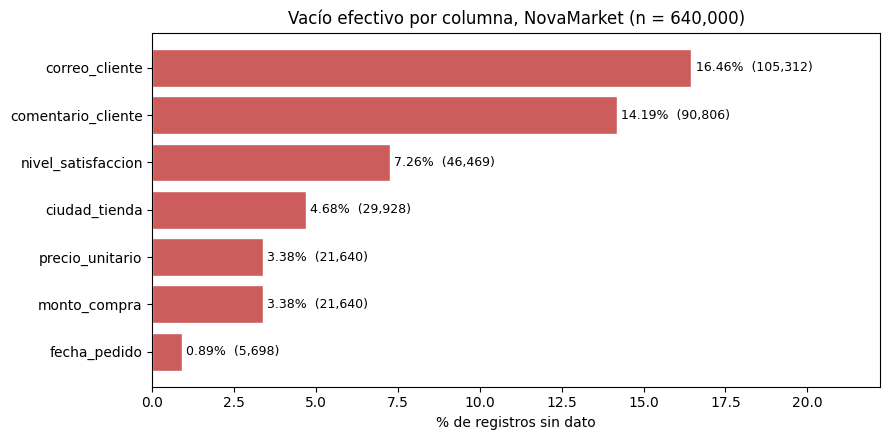

In [9]:
viz = (tabla_completitud[tabla_completitud["Vacio efectivo"] > 0]
       .sort_values("% vacio efectivo"))

plt.figure(figsize=(9, 4.5))
barras = plt.barh(viz["Columna"], viz["% vacio efectivo"],
                  color="indianred", edgecolor="white")
plt.bar_label(barras,
              labels=[f"{p:.2f}%  ({v:,})" for p, v in
                      zip(viz["% vacio efectivo"], viz["Vacio efectivo"])],
              padding=3, fontsize=9)
plt.title(f"Vacío efectivo por columna, NovaMarket (n = {n:,})")
plt.xlabel("% de registros sin dato")
plt.xlim(0, viz["% vacio efectivo"].max() * 1.35)
plt.tight_layout()
plt.show()

## Hallazgos de completitud

Se midió el **vacío efectivo** (celda vacía, cadena de solo espacios o centinela textual) en **las 20 columnas**. Siete presentan vacíos y trece están completas.

| Columna afectada | Registros vacíos | % del dataset | Cómo se representa el faltante |
|---|---:|---:|---|
| `correo_cliente` | 105 312 | 16.46% | Celda vacía |
| `comentario_cliente` | 90 806 | 14.19% | Celda vacía |
| `nivel_satisfaccion` | 46 469 | 7.26% | Celda vacía |
| `ciudad_tienda` | 29 928 | 4.68% | Celda vacía |
| `precio_unitario` | 21 640 | 3.38% | Celda vacía |
| `monto_compra` | 21 640 | 3.38% | Celda vacía |
| `fecha_pedido` | 5 698 | 0.89% | Texto `00/00/0000` |

**Columnas sin ningún vacío (13):** `id_pedido`, `id_cliente`, `canal_compra`, `metodo_pago`, `codigo_postal`, `categoria_producto`, `producto`, `unidades_vendidas`, `edad_cliente`, `nivel_lealtad`, `peso_pedido_kg`, `fecha_actualizacion_stock`, `fuga_cliente`.

**Sobre los «falsos completos».** Se verificaron 41 centinelas (`-`, `--`, `N/A`, `NA`, `ND`, `S/D`, `sin dato`, `sin datos`, `desconocido`, `no aplica`, `ninguno`, `null`, `none`, `?`, `.`, `x`, `missing`, `0000-00-00`, `00/00/0000`, entre otros) sobre las 20 columnas, leyendo el archivo en texto crudo con `keep_default_na=False` para que pandas no los convirtiera a `NaN` de forma silenciosa.

**Apareció uno, y es el que importa:** `fecha_pedido` trae 5 698 celdas con el texto `00/00/0000`. Con el conteo tradicional de `isnull()` esa columna figura como completa al 100%, porque las celdas tienen contenido; el replanteamiento de la medición es justamente lo que las saca a la luz. Ninguna columna tiene celdas con solo espacios.

**Nota sobre solapamiento.** Esos mismos 5 698 registros vuelven a aparecer en validez, dentro de los 22 687 valores de `fecha_pedido` que no se pueden convertir a fecha. Son el mismo dato visto desde dos dimensiones: **falta** (completitud) y además **está escrito con forma de fecha sin serlo** (validez). No deben sumarse.

**Decisión metodológica: por qué `-1` no está en el catálogo de centinelas.** En muchos sistemas `-1` se usa para decir «sin dato». Aquí se dejó fuera a propósito, ya que en las columnas numéricas de este archivo es un valor de pleno derecho: incluirlo marcaría como faltantes las 9 357 filas con `unidades_vendidas = -1`, que ya se cuentan en validez como violación de dominio. Contarlas dos veces inflaría el diagnóstico.

**Reglas de dominio.** Se aplican primero las cuatro reglas base del enunciado y después tres reglas propias añadidas para este dataset. Cada regla se evalúa por separado y se reporta su conteo exacto.

In [10]:
# --- Reglas base del enunciado -------------------------------------------------
precio_negativo   = df[df["precio_unitario"] < 0]
precio_excesivo   = df[df["precio_unitario"] > 10_000_000]
unidades_negativas = df[df["unidades_vendidas"] < 0]
edad_fuera_rango  = df[(df["edad_cliente"] < 0) | (df["edad_cliente"] > 120)]

print(f"precio_unitario negativo                : {len(precio_negativo):,}")
print(f"precio_unitario mayor a $10.000.000     : {len(precio_excesivo):,}")
print(f"unidades_vendidas negativas             : {len(unidades_negativas):,}")
print(f"edad_cliente fuera del rango 0 a 120    : {len(edad_fuera_rango):,}")

precio_unitario negativo                : 19,629
precio_unitario mayor a $10.000.000     : 6,164
unidades_vendidas negativas             : 18,550
edad_cliente fuera del rango 0 a 120    : 27,829


In [11]:
# --- Reglas de dominio PROPIAS, añadidas para este dataset ---------------------
# 1. monto_compra debe ser positivo (es el valor cobrado por el pedido)
monto_no_positivo = df[df["monto_compra"] <= 0]

# 2. unidades_vendidas igual a cero: un pedido registrado sin unidades no existe
unidades_cero = df[df["unidades_vendidas"] == 0]

# 3. peso_pedido_kg superior a 100 kg: el catalogo son bienes de consumo de
#    tamaño medio (ropa, audifonos, cremas); un pedido de mas de 100 kg no es plausible
peso_implausible = df[df["peso_pedido_kg"] > 100]

# 4. unidades_vendidas por encima de 1 000: fuera de toda escala minorista
unidades_extremas = df[df["unidades_vendidas"] > 1000]

print(f"monto_compra menor o igual a cero        : {len(monto_no_positivo):,}")
print(f"unidades_vendidas igual a cero           : {len(unidades_cero):,}")
print(f"peso_pedido_kg mayor a 100 kg            : {len(peso_implausible):,}")
print(f"unidades_vendidas mayor a 1 000          : {len(unidades_extremas):,}")
print()
print("Valores concretos que toman las unidades extremas:",
      sorted(unidades_extremas["unidades_vendidas"].unique()))
print("Valor maximo de precio_unitario:", f"{df['precio_unitario'].max():,.0f}")

monto_compra menor o igual a cero        : 45,182
unidades_vendidas igual a cero           : 9,327
peso_pedido_kg mayor a 100 kg            : 32,045
unidades_vendidas mayor a 1 000          : 18,526

Valores concretos que toman las unidades extremas: [np.int64(5000), np.int64(9999)]
Valor maximo de precio_unitario: 999,000,000


In [12]:
# Consolidado de todas las reglas de dominio
reglas_dominio = [
    ("precio_unitario",   "precio_unitario < 0",                 len(precio_negativo),   "base"),
    ("precio_unitario",   "precio_unitario > 10.000.000",        len(precio_excesivo),   "base"),
    ("unidades_vendidas", "unidades_vendidas < 0",               len(unidades_negativas),"base"),
    ("edad_cliente",      "edad_cliente < 0 o > 120",            len(edad_fuera_rango),  "base"),
    ("monto_compra",      "monto_compra <= 0",                   len(monto_no_positivo), "propia"),
    ("unidades_vendidas", "unidades_vendidas == 0",              len(unidades_cero),     "propia"),
    ("peso_pedido_kg",    "peso_pedido_kg > 100 kg",             len(peso_implausible),  "propia"),
    ("unidades_vendidas", "unidades_vendidas > 1.000",           len(unidades_extremas), "propia"),
]

tabla_dominio = pd.DataFrame(reglas_dominio,
                             columns=["Columna", "Regla de dominio", "Registros afectados", "Origen"])
tabla_dominio["% del dataset"] = (tabla_dominio["Registros afectados"] / n * 100).round(2)
tabla_dominio = tabla_dominio.sort_values("Registros afectados", ascending=False)
display(tabla_dominio.style.hide(axis="index")
        .format({"Registros afectados": "{:,.0f}", "% del dataset": "{:.2f}%"}))

print("Ninguna regla devolvio cero registros: las ocho detectan problemas reales.")
print()
print("Desglose negativos / ceros por columna:")
for col in ["precio_unitario", "unidades_vendidas", "monto_compra", "edad_cliente"]:
    s = df[col]
    print(f"  {col:20s} negativos={int((s < 0).sum()):>7,}   ceros={int((s == 0).sum()):>7,}")

Columna,Regla de dominio,Registros afectados,Origen,% del dataset
monto_compra,monto_compra <= 0,"45,182",propia,7.06%
peso_pedido_kg,peso_pedido_kg > 100 kg,"32,045",propia,5.01%
edad_cliente,edad_cliente < 0 o > 120,"27,829",base,4.35%
precio_unitario,precio_unitario < 0,"19,629",base,3.07%
unidades_vendidas,unidades_vendidas < 0,"18,550",base,2.90%
unidades_vendidas,unidades_vendidas > 1.000,"18,526",propia,2.89%
unidades_vendidas,unidades_vendidas == 0,"9,327",propia,1.46%
precio_unitario,precio_unitario > 10.000.000,"6,164",base,0.96%


Ninguna regla devolvio cero registros: las ocho detectan problemas reales.

Desglose negativos / ceros por columna:
  precio_unitario      negativos= 19,629   ceros=      0
  unidades_vendidas    negativos= 18,550   ceros=  9,327
  monto_compra         negativos= 36,172   ceros=  9,010
  edad_cliente         negativos=  9,254   ceros=  9,323


**Rangos numéricos.** Cada variable de razón se contrasta contra su dominio admisible.

In [13]:
reglas = {
    "precio_unitario":   (lambda s: s <= 0,                 "precio de venta debe ser > 0"),
    "unidades_vendidas": (lambda s: s <= 0,                 "una compra debe tener al menos 1 unidad"),
    "monto_compra":      (lambda s: s <= 0,                 "el monto de un pedido debe ser > 0"),
    "edad_cliente":      (lambda s: (s < 0) | (s > 120),    "edad humana plausible: 0 a 120"),
    "peso_pedido_kg":    (lambda s: s <= 0,                 "el peso debe ser > 0"),
}

filas = []
for col, (es_invalido, regla) in reglas.items():
    serie     = df[col]
    invalidos = int(es_invalido(serie).fillna(False).sum())
    nulos     = int(serie.isna().sum())
    filas.append({
        "Columna":    col,
        "Regla":      regla,
        "Validos":    n - invalidos - nulos,
        "Invalidos":  invalidos,
        "Nulos":      nulos,
        "% Falla":    f"{invalidos / n * 100:.2f}%",
    })

audit_rangos = pd.DataFrame(filas)
display(audit_rangos.style.hide(axis="index"))

# Desglose de los invalidos: negativos frente a ceros
print("Desglose negativos / ceros:")
for col in ["precio_unitario", "unidades_vendidas", "monto_compra", "edad_cliente"]:
    s = df[col]
    print(f"  {col:20s} negativos={int((s < 0).sum()):>7,}   ceros={int((s == 0).sum()):>7,}")

Columna,Regla,Validos,Invalidos,Nulos,% Falla
precio_unitario,precio de venta debe ser > 0,598731,19629,21640,3.07%
unidades_vendidas,una compra debe tener al menos 1 unidad,612123,27877,0,4.36%
monto_compra,el monto de un pedido debe ser > 0,573178,45182,21640,7.06%
edad_cliente,edad humana plausible: 0 a 120,612171,27829,0,4.35%
peso_pedido_kg,el peso debe ser > 0,640000,0,0,0.00%


Desglose negativos / ceros:
  precio_unitario      negativos= 19,629   ceros=      0
  unidades_vendidas    negativos= 18,550   ceros=  9,327
  monto_compra         negativos= 36,172   ceros=  9,010
  edad_cliente         negativos=  9,254   ceros=  9,323


**Valores atípicos extremos.** Además de los valores imposibles, hay observaciones dentro del dominio pero fuera de toda escala plausible del negocio.

In [14]:
atipicos = {
    "unidades_vendidas": (df["unidades_vendidas"] > 1000,  "más de 1 000 unidades en un pedido"),
    "precio_unitario":   (df["precio_unitario"] > 1e8,     "precio unitario por encima de 100 millones"),
    "peso_pedido_kg":    (df["peso_pedido_kg"] > 100,      "pedido de más de 100 kg"),
    "monto_compra":      (df["monto_compra"].abs() > 1e9,  "monto por encima de 1 000 millones"),
}

filas = []
for col, (mask, desc) in atipicos.items():
    k = int(mask.fillna(False).sum())
    filas.append({
        "Columna":   col,
        "Criterio":  desc,
        "Registros": k,
        "%":         f"{k / n * 100:.2f}%",
        "Valores":   ", ".join(map(str, sorted(df.loc[mask.fillna(False), col].unique())[:6])),
    })

audit_atipicos = pd.DataFrame(filas)
display(audit_atipicos.style.hide(axis="index"))

Columna,Criterio,Registros,%,Valores
unidades_vendidas,más de 1 000 unidades en un pedido,18526,2.89%,"5000, 9999"
precio_unitario,precio unitario por encima de 100 millones,3050,0.48%,999000000.0
peso_pedido_kg,pedido de más de 100 kg,32045,5.01%,"900.0, 900.1, 900.2, 900.3, 900.4, 900.5"
monto_compra,monto por encima de 1 000 millones,16158,2.52%,"-8580141900.0, -8244175500.0, -8141185800.0, -7898210100.0, -7692230700.0, -7485251400.0"


**Visualización de dispersión y valores fuera de rango.** Para cada variable numérica con regla de dominio se muestran dos vistas complementarias. A la izquierda, un **gráfico de dispersión en escala symlog**: cada punto es un registro, los que violan la regla aparecen en rojo y la línea punteada marca el umbral; así se ven a la vez el grueso de los datos y los valores imposibles. A la derecha, un **boxplot con la escala ajustada** al rango de Tukey (Q1−1.5·IQR a Q3+1.5·IQR), que hace visible la caja y los bigotes, imposible de apreciar a escala completa porque los outliers la aplastan contra el cero.

Dado el volumen del dataset se grafica una **muestra aleatoria de 20 000 registros** para la dispersión (los conteos de las tablas se calculan siempre sobre los 640 000).

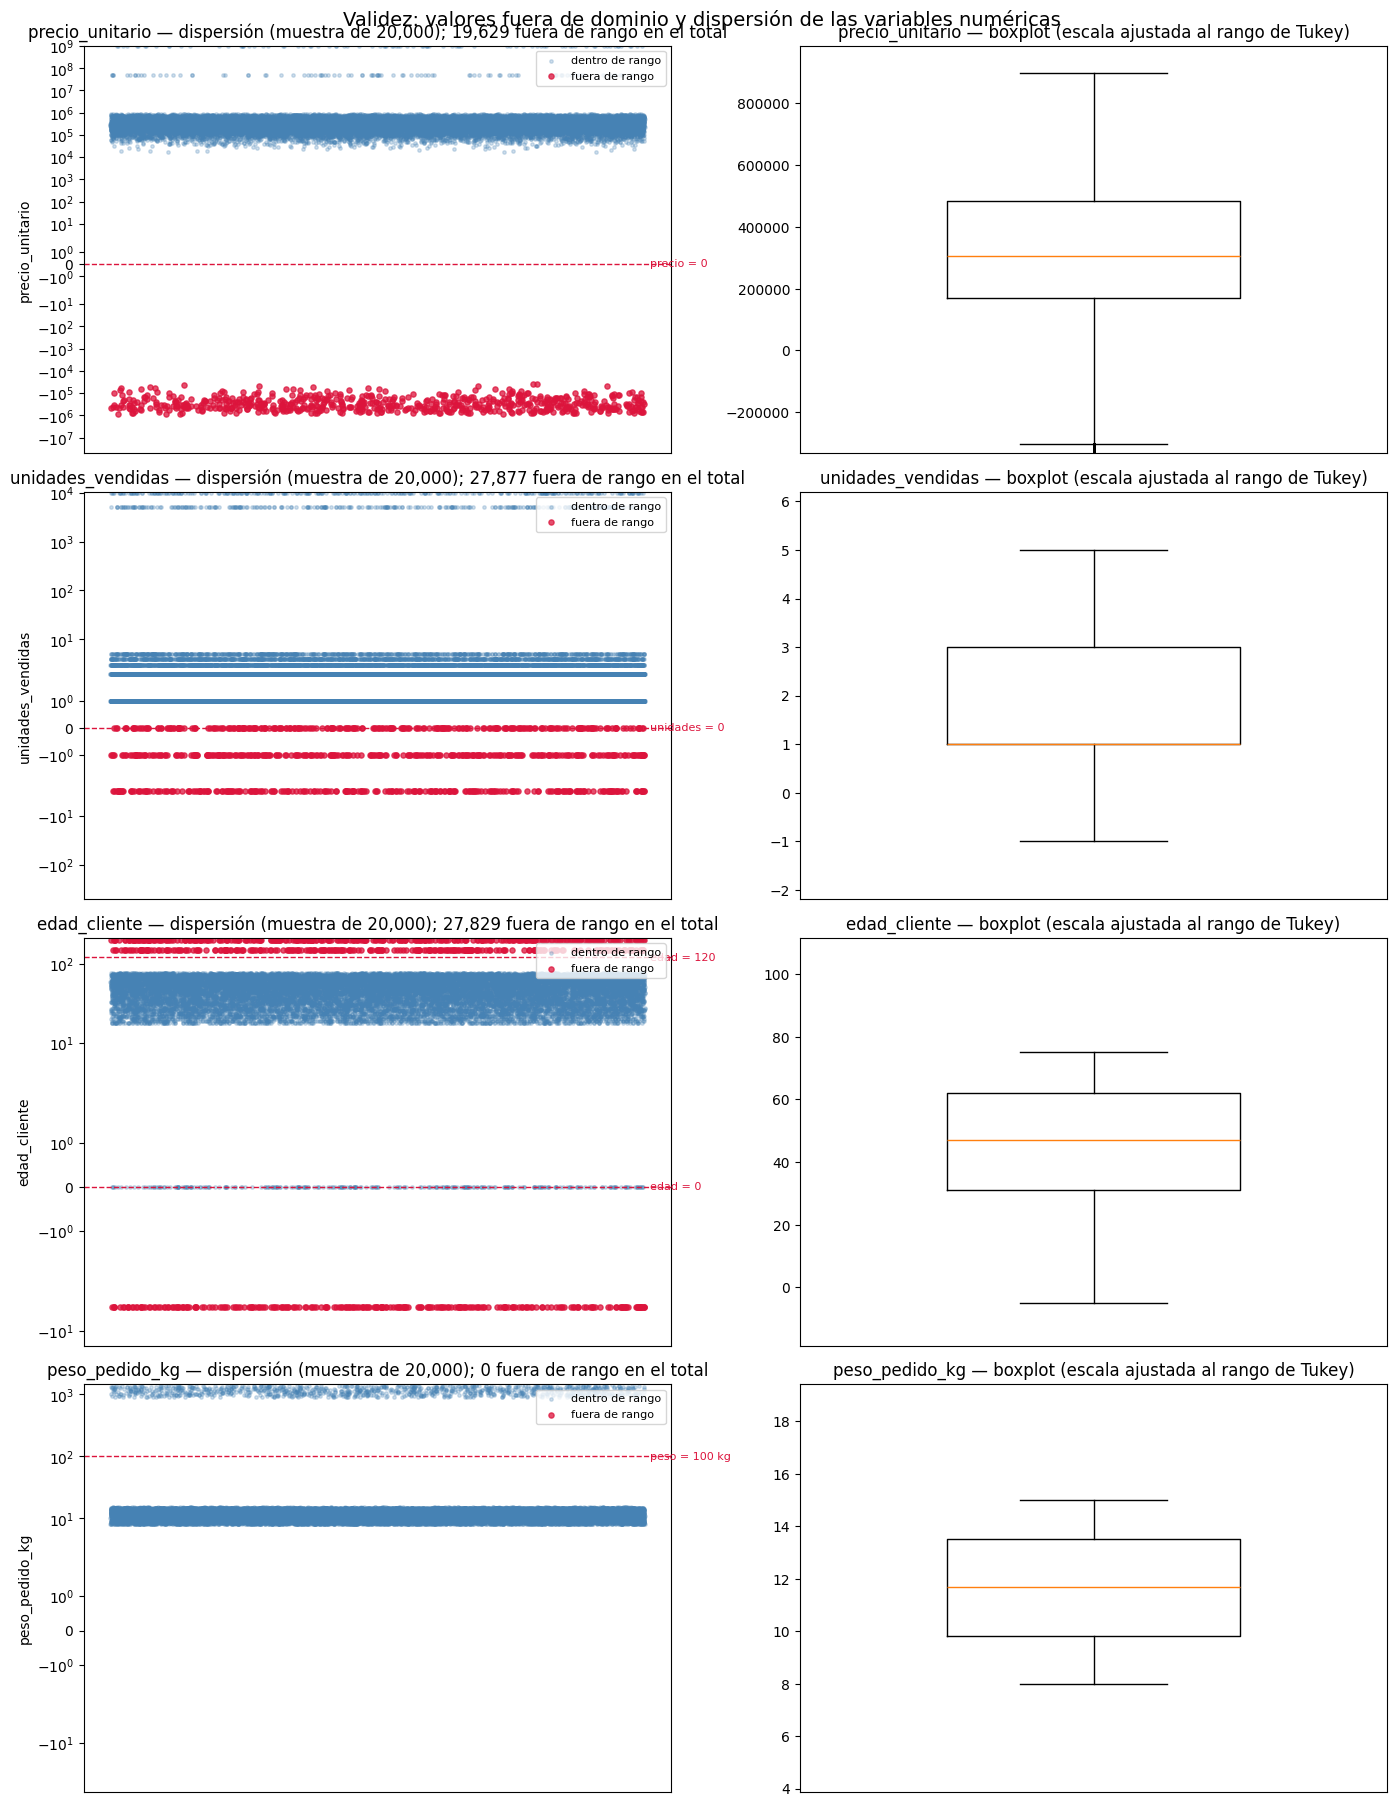

In [15]:
reglas_viz = {
    "precio_unitario":   {"invalido": lambda s: s <= 0,              "umbral": [(0, "precio = 0")]},
    "unidades_vendidas": {"invalido": lambda s: s <= 0,              "umbral": [(0, "unidades = 0")]},
    "edad_cliente":      {"invalido": lambda s: (s < 0) | (s > 120), "umbral": [(0, "edad = 0"), (120, "edad = 120")]},
    "peso_pedido_kg":    {"invalido": lambda s: s <= 0,              "umbral": [(100, "peso = 100 kg")]},
}

rng = np.random.default_rng(0)
N_MUESTRA = 20_000

fig, axes = plt.subplots(len(reglas_viz), 2, figsize=(14, 4.6 * len(reglas_viz)))

for fila, (col, cfg) in enumerate(reglas_viz.items()):
    serie_full = df[col].dropna()
    mask_full  = cfg["invalido"](serie_full)

    # Muestra para la dispersion (los conteos del titulo son sobre el total)
    idx = rng.choice(len(serie_full), size=min(N_MUESTRA, len(serie_full)), replace=False)
    serie = serie_full.iloc[idx]
    mask  = cfg["invalido"](serie)
    x = rng.uniform(0, 1, size=len(serie))

    ax = axes[fila, 0]
    ax.scatter(x[~mask.values], serie[~mask.values], s=6, alpha=0.25,
               color="steelblue", label="dentro de rango")
    ax.scatter(x[mask.values], serie[mask.values], s=14, alpha=0.75,
               color="crimson", label="fuera de rango")
    for u, etiqueta in cfg["umbral"]:
        ax.axhline(u, color="crimson", linestyle="--", linewidth=1)
        ax.text(1.01, u, etiqueta, color="crimson", fontsize=8, va="center")
    ax.set_yscale("symlog")
    ax.set_xticks([])
    ax.set_ylabel(col)
    ax.set_title(f"{col} — dispersión (muestra de {len(serie):,});"
                 f" {int(mask_full.sum()):,} fuera de rango en el total")
    ax.legend(fontsize=8, loc="upper right")

    ax = axes[fila, 1]
    ax.boxplot(serie_full.values, vert=True, widths=0.5,
               flierprops=dict(marker=".", markersize=2, alpha=0.3))
    q1, q3 = serie_full.quantile([0.25, 0.75])
    iqr = q3 - q1
    ax.set_ylim(q1 - 1.6 * iqr, q3 + 1.6 * iqr)
    ax.set_xticks([])
    ax.set_title(f"{col} — boxplot (escala ajustada al rango de Tukey)")

plt.suptitle("Validez: valores fuera de dominio y dispersión de las variables numéricas",
             fontsize=14)
plt.tight_layout()
plt.show()

### Exactitud

La exactitud pregunta si el valor registrado **corresponde a la realidad que dice representar**. A diferencia de la validez, que solo mira la forma, aquí hay que contrastar el contenido contra algo: una fuente externa, otra columna del mismo registro o el comportamiento del propio campo a lo largo de la base.

**Paso previo: perfilar qué contiene realmente cada campo.** Antes de cruzar nada conviene mirar el contenido de cada columna agrupándolo, porque es la forma más directa de detectar valores que no tienen sentido para lo que el campo dice ser. Ahora bien, *agrupar por valor* no sirve igual en todas las columnas, y por eso se separan en tres familias con un método distinto cada una:

| Familia | Cómo se perfila | Columnas |
|---|---|---|
| **A. Catalogables** — pocas categorías, existe una lista cerrada de valores legítimos | Se agrupan **todos** los valores y se listan completos; cualquier valor ajeno al catálogo salta a la vista | `canal_compra`, `metodo_pago`, `nivel_satisfaccion`, `nivel_lealtad`, `categoria_producto`, `producto`, `fuga_cliente`, `comentario_cliente` |
| **B. Con forma esperada** — miles de valores distintos, pero todos deben seguir un patrón | Agrupar por valor no dice nada (cada uno aparece una vez); se agrupa por la **firma del patrón**, sustituyendo dígitos por `9` y letras por `a` | `id_pedido`, `id_cliente`, `correo_cliente`, `fecha_pedido`, `fecha_actualizacion_stock`, `codigo_postal` |
| **C. Cuantitativas** — valores continuos sin catálogo posible | Agrupar valor por valor no tiene sentido; se juzgan por **rango, percentiles y unidad de medida**, contrastando contra lo plausible en el negocio | `precio_unitario`, `unidades_vendidas`, `monto_compra`, `edad_cliente`, `peso_pedido_kg` |

**Familia A — columnas catalogables: se listan todos sus valores.**

In [16]:
CATALOGABLES = ["canal_compra", "metodo_pago", "nivel_satisfaccion", "nivel_lealtad",
                "categoria_producto", "producto", "fuga_cliente", "comentario_cliente"]

filas = []
for col in CATALOGABLES:
    vc      = df[col].value_counts(dropna=True)
    vc_norm = df[col].map(base_texto).value_counts(dropna=True) if df[col].dtype == object \
              else df[col].value_counts(dropna=True)
    filas.append({
        "Columna":              col,
        "Valores distintos":    int(df[col].nunique()),
        "Tras normalizar":      int(len(vc_norm)),
        "Menos frecuente":      f"{vc.index[-1]!r} ({vc.iloc[-1]:,})",
        "Más frecuente":        f"{vc.index[0]!r} ({vc.iloc[0]:,})",
        "Ratio máx/mín":        f"{vc.iloc[0] / vc.iloc[-1]:.1f}x",
    })

display(pd.DataFrame(filas).style.hide(axis="index"))

print("Listado completo de las columnas de catalogo corto:")
for col in ["canal_compra", "metodo_pago", "nivel_satisfaccion", "nivel_lealtad", "fuga_cliente"]:
    valores = sorted(map(str, df[col].dropna().map(base_texto).unique())) \
              if df[col].dtype == object else sorted(map(str, df[col].dropna().unique()))
    print(f"  {col:20s} -> {valores}")

Columna,Valores distintos,Tras normalizar,Menos frecuente,Más frecuente,Ratio máx/mín
canal_compra,20,20,"' App' (7,586)","'Marketplace' (121,426)",16.0x
metodo_pago,20,20,"'TRANSFERENCIA' (6,284)","'Transferencia' (127,962)",20.4x
nivel_satisfaccion,15,15,"'Bajo ' (6,268)","'Alto' (166,739)",26.6x
nivel_lealtad,4,4,"'Platino' (159,446)","'Bronce' (160,420)",1.0x
categoria_producto,32,32,"' Hogar' (9,945)","'Belleza' (56,378)",5.7x
producto,24,24,"'Bufanda de lana' (26,375)","'Parlante bluetooth' (27,016)",1.0x
fuga_cliente,2,2,"np.int64(1) (133,777)","np.int64(0) (506,223)",3.8x
comentario_cliente,12,12,"'Rápido y sin problemas' (45,458)","'No era lo que esperaba' (46,107)",1.0x


Listado completo de las columnas de catalogo corto:
  canal_compra         -> [' App', ' Marketplace', ' Tienda', ' Web', 'APP', 'App', 'App ', 'MARKETPLACE', 'Marketplace', 'Marketplace ', 'TIENDA', 'Tienda', 'Tienda ', 'WEB', 'Web', 'Web ', 'app', 'marketplace', 'tienda', 'web']
  metodo_pago          -> [' Efectivo', ' PayPal', ' Tarjeta', ' Transferencia', 'EFECTIVO', 'Efectivo', 'Efectivo ', 'PAYPAL', 'PayPal', 'PayPal ', 'TARJETA', 'TRANSFERENCIA', 'Tarjeta', 'Tarjeta ', 'Transferencia', 'Transferencia ', 'efectivo', 'paypal', 'tarjeta', 'transferencia']
  nivel_satisfaccion   -> [' Alto', ' Bajo', ' Medio', 'ALTO', 'Alto', 'Alto ', 'BAJO', 'Bajo', 'Bajo ', 'MEDIO', 'Medio', 'Medio ', 'alto', 'bajo', 'medio']
  nivel_lealtad        -> ['Bronce', 'Oro', 'Plata', 'Platino']
  fuga_cliente         -> ['0', '1']


**Lectura de la familia A.** Ninguna de las ocho columnas contiene un valor ajeno a su significado: tras normalizar la escritura, `canal_compra` se reduce a los cuatro canales esperados, `metodo_pago` a los cuatro medios de pago, `nivel_satisfaccion` a los tres niveles, `nivel_lealtad` a los cuatro segmentos, `categoria_producto` a seis categorías, `producto` a 24 artículos y `comentario_cliente` a 12 reseñas de plantilla. El problema de estas columnas es **de escritura, no de contenido**: no hay ningún valor que no pertenezca al campo, y por eso su diagnóstico corresponde a consistencia y no a exactitud.

**Familia B — columnas con forma esperada: se agrupan por la firma del patrón.** La firma se construye sustituyendo cada dígito por `9`, cada letra por `a` y comprimiendo las repeticiones con `+`. Así, `P505195` se convierte en `a9+` y `cliente405195@novamarket.com.co` en `a+9+@a+.a+.a+`. Agrupando por esa firma se ve de un vistazo cuántas formas distintas conviven dentro de una misma columna y cuáles no corresponden a lo que el campo debería contener.

In [17]:
def firma_patron(v):
    """Reduce un valor a su forma: digitos -> 9, letras -> a, repeticiones -> '+'."""
    if pd.isna(v):
        return "<vacío>"
    s = re.sub(r"\d", "9", str(v))
    s = re.sub(r"[^\W\d_]", "a", s, flags=re.UNICODE)
    return re.sub(r"(.)\1+", lambda m: m.group(1) + "+", s)

CON_FORMA = ["id_pedido", "id_cliente", "correo_cliente",
             "fecha_pedido", "fecha_actualizacion_stock", "codigo_postal"]

for col in CON_FORMA:
    # Se calcula la firma UNA sola vez por columna y se reutiliza para el conteo y para
    # el ejemplo; recalcularla dentro del bucle multiplicaria el costo por el nº de firmas.
    firma_col = df[col].map(firma_patron)
    conteo = firma_col.value_counts(dropna=False)

    ejemplos = (pd.DataFrame({"firma": firma_col, "valor": df[col]})
                  .dropna(subset=["valor"])
                  .groupby("firma")["valor"].first())

    tabla = conteo.rename_axis("firma").reset_index(name="registros")
    tabla["%"] = (tabla["registros"] / n * 100).round(2).astype(str) + "%"
    tabla["ejemplo"] = [repr(ejemplos[f]) if f in ejemplos.index else "—"
                        for f in tabla["firma"]]

    print(f"\n=== {col} — {len(tabla)} forma(s) distinta(s) ===")
    display(tabla.style.hide(axis="index"))


=== id_pedido — 1 forma(s) distinta(s) ===


firma,registros,%,ejemplo
a9+,640000,100.0%,'P505195'



=== id_cliente — 1 forma(s) distinta(s) ===


firma,registros,%,ejemplo
a9+,640000,100.0%,'C45650'



=== correo_cliente — 7 forma(s) distinta(s) ===


...

firma,registros,%,ejemplo
9+/9+/9+,259070,40.48%,'15/11/2025'
9+-9+-9+,205992,32.19%,'2026-03-05'
9+/9/9+,113541,17.74%,'10/3/2026'
9/9/9+,50601,7.91%,'1/1/2026'
9/9+/9+,10796,1.69%,'7/10/2025'



=== fecha_actualizacion_stock — 1 forma(s) distinta(s) ===


firma,registros,%,ejemplo
9+-9+-9+,640000,100.0%,'2026-04-17'



=== codigo_postal — 1 forma(s) distinta(s) ===


firma,registros,%,ejemplo
9+,640000,100.0%,np.int64(1100103)


**Lectura de la familia B.**

- `id_pedido`, `id_cliente`, `codigo_postal` y `fecha_actualizacion_stock` tienen **una sola firma** cada una: su contenido es homogéneo y corresponde a lo que el campo declara.
- `fecha_pedido` presenta **cinco firmas**, que son las dos convenciones (ISO y barras) más las variantes de día o mes sin cero a la izquierda. Es el problema de formato ya cuantificado en validez.
- `correo_cliente` presenta **siete firmas**. Cuatro de ellas contienen `@` y son correos legítimos; dos de ellas —`a+9+.a+.a+` con 41 144 registros y `a+9+.a+.a+.a+` con 10 388— **carecen de arroba** y por tanto no son direcciones de correo aunque ocupen la columna de correo. La suma es 51 532, exactamente la cifra de correos inválidos de la sección de validez, lo cual sirve de verificación cruzada entre los dos métodos.

**Familia C — columnas cuantitativas: se perfilan por rango y percentiles.** No existe catálogo contra el cual comparar, así que la pregunta se reformula: ¿los valores caben dentro de lo que la magnitud admite? Se contrastan los extremos observados contra el rango plausible del negocio y se mide qué proporción de la masa de datos queda fuera.

In [18]:
RANGO_PLAUSIBLE = {
    "precio_unitario":   (1,   5_000_000,  "COP por unidad; el catálogo son bienes de consumo"),
    "unidades_vendidas": (1,   100,        "unidades por pedido minorista"),
    "monto_compra":      (1,   500_000_000,"COP por pedido"),
    "edad_cliente":      (18,  100,        "edad de un cliente que puede comprar"),
    "peso_pedido_kg":    (0.1, 100,        "kg por pedido despachado"),
}

filas = []
for col, (lo, hi, nota) in RANGO_PLAUSIBLE.items():
    s = df[col].dropna()
    q = s.quantile([0.001, 0.25, 0.50, 0.75, 0.999])
    fuera = ((s < lo) | (s > hi)).sum()
    filas.append({
        "Columna":            col,
        "Mín observado":      f"{s.min():,.1f}",
        "p0.1%":              f"{q.loc[0.001]:,.1f}",
        "Mediana":            f"{q.loc[0.50]:,.1f}",
        "p99.9%":             f"{q.loc[0.999]:,.1f}",
        "Máx observado":      f"{s.max():,.1f}",
        "Rango plausible":    f"[{lo:,} , {hi:,}]",
        "Fuera del rango":    int(fuera),
        "%":                  f"{fuera / n * 100:.2f}%",
    })

display(pd.DataFrame(filas).style.hide(axis="index"))
print("Interpretación: en las cinco columnas la mediana es perfectamente razonable, pero los")
print("extremos no lo son. El contraste entre el percentil 99.9 y el máximo es la señal más")
print("clara: los valores imposibles son inyecciones puntuales, no una distribución sesgada.")

Columna,Mín observado,p0.1%,Mediana,p99.9%,Máx observado,Rango plausible,Fuera del rango,%
precio_unitario,"-888,100.0","-751,600.0","305,600.0","999,000,000.0","999,000,000.0","[1 , 5,000,000]",25793,4.03%
unidades_vendidas,-3.0,-3.0,1.0,"9,999.0","9,999.0","[1 , 100]",46403,7.25%
monto_compra,"-8,580,141,900.0","-582,424,129.7","456,500.0","7,084,932,435.9","9,989,001,000,000.0","[1 , 500,000,000]",64539,10.08%
edad_cliente,-5.0,-5.0,47.0,200.0,200.0,"[18 , 100]",37152,5.80%
peso_pedido_kg,8.0,8.0,11.7,"1,390.0","1,399.9","[0.1 , 100]",32045,5.01%


Interpretación: en las cinco columnas la mediana es perfectamente razonable, pero los
extremos no lo son. El contraste entre el percentil 99.9 y el máximo es la señal más
clara: los valores imposibles son inyecciones puntuales, no una distribución sesgada.


**Lectura de la familia C.** La mediana de cada variable es plausible (precio unitario ≈ 306 000 COP, 1 unidad por pedido, 47 años, 11.7 kg), pero los extremos no lo son: precios negativos de hasta −888 100, un máximo de 999 000 000 repetido idénticamente en los 24 productos, unidades de 5 000 y 9 999, edades de −5 y 200, y pesos de hasta 1 399.9 kg, sobre una mediana de 11.7 kg. Que el máximo de precio sea **exactamente el mismo valor en los 24 productos** apunta a un tope o marcador del sistema de origen antes que a precios reales mal digitados. Es un punto a confirmar con el área responsable, ya que de ello depende si esos registros se descartan o se reprocesan.

Este es el punto que distingue esta familia de las anteriores: no se puede decir que 999 000 000 «no pertenezca al catálogo de precios», porque no existe tal catálogo. Lo que se puede afirmar es que ningún artículo de este surtido cuesta mil millones de pesos, y esa afirmación viene del conocimiento del negocio, no de la estructura del dato.

#### Cruces de exactitud

Con el perfilado hecho, se contrastan los campos entre sí y contra la fuente externa. Se auditan **nueve reglas**: una contra fuente oficial (DIVIPOLA del DANE) y ocho de coherencia interna entre columnas del propio registro.

**Cruce 1 `codigo_postal` contra `ciudad_tienda` (fuente externa: DIVIPOLA, DANE).** El `codigo_postal` de esta versión tiene **siete dígitos** y su estructura es jerárquica: los **cinco primeros son el código de municipio de la codificación DIVIPOLA del DANE** y los dos últimos identifican la sede dentro del municipio. Verificando los 493 códigos distintos del archivo, sus cinco primeros dígitos se reducen a **doce municipios**, exactamente los doce de las tiendas de NovaMarket.

Se compara el municipio que el código representa oficialmente contra la ciudad declarada, previa normalización de esta última: sin ella, cada variante de escritura contaría como discrepancia y la cifra se inflaría artificialmente. **Los 29 928 registros sin ciudad se excluyen del cálculo**: no son un dato equivocado sino un dato ausente, ya contabilizado en completitud, y contarlos aquí sería computar el mismo problema dos veces.

In [19]:
# Catalogo DIVIPOLA de los municipios presentes (fuente: DANE, codificacion oficial).
# Se intenta primero la descarga del catalogo de datos abiertos; si no hay conectividad
# se usa el diccionario embebido, que cubre los 12 municipios del dataset.
DANE_MUNICIPIOS = {
    "05001": "medellin",     "08001": "barranquilla", "11001": "bogota",
    "13001": "cartagena",    "17001": "manizales",    "47001": "santa marta",
    "50001": "villavicencio","54001": "cucuta",       "66001": "pereira",
    "68001": "bucaramanga",  "73001": "ibague",       "76001": "cali",
}

try:
    ref = pd.read_csv("https://www.datos.gov.co/resource/ixig-z8b5.csv?$limit=50000")
    ref["codmun"] = ref["codigo_municipio"].astype(str).str.zfill(5)
    # IMPORTANTE: el nombre oficial se normaliza con la MISMA funcion que la ciudad de la
    # base (normalizar_ciudad), no solo con base_texto. El DANE registra "Bogota, D.C.",
    # "Santiago de Cali" o "Cartagena de Indias", y comparar esos nombres largos contra
    # "bogota", "cali" o "cartagena" marcaria como discrepancia toda la ciudad.
    ref["municipio_norm"] = ref["nombre_municipio"].map(normalizar_ciudad)
    catalogo = ref.groupby("codmun")["municipio_norm"].first().to_dict()
    print(f"Catalogo DANE descargado en linea: {len(catalogo):,} municipios.")
except Exception as e:
    catalogo = DANE_MUNICIPIOS
    print(f"No se pudo descargar el catalogo en linea ({type(e).__name__}).")
    print(f"Se usa el catalogo DIVIPOLA embebido: {len(catalogo)} municipios,")
    print("suficiente para los codigos presentes en el dataset.")

cp7    = df["codigo_postal"].astype("Int64").astype("string").str.zfill(7)
codmun = cp7.str[:5]

print(f"\nCodigos postales distintos: {cp7.nunique()}")
print(f"Municipios distintos (5 primeros digitos): {codmun.nunique()}")
print(f"Codigos cuyo municipio NO esta en el catalogo: {(~codmun.isin(catalogo)).sum()}")

# Control de calidad DE LA FUENTE: el catalogo que se vaya a usar debe devolver, para los
# 12 municipios del dataset, exactamente los 12 nombres canonicos. Si una sola ciudad no
# coincide, la comparacion posterior contaria ~47 000 discrepancias falsas de esa ciudad.
nombres_catalogo = {c: catalogo.get(c) for c in sorted(codmun.unique())}
esperados = set(DANE_MUNICIPIOS.values())
desalineados = {c: v for c, v in nombres_catalogo.items() if v not in esperados}

print("\nControl de la fuente de referencia (12 municipios del dataset):")
for c, v in nombres_catalogo.items():
    marca = "OK " if v in esperados else "REVISAR"
    print(f"  {c} -> {v!r:20s} {marca}")

if desalineados:
    print(f"\n{len(desalineados)} municipio(s) sin forma canonica: {desalineados}")
    print("Se usa el catalogo embebido para no inflar el conteo de discrepancias.")
    catalogo = DANE_MUNICIPIOS
else:
    print("\nLos 12 nombres coinciden con la forma canonica. El catalogo es utilizable.")

No se pudo descargar el catalogo en linea (URLError).
Se usa el catalogo DIVIPOLA embebido: 12 municipios,
suficiente para los codigos presentes en el dataset.



Codigos postales distintos: 493
Municipios distintos (5 primeros digitos): 12
Codigos cuyo municipio NO esta en el catalogo: 0

Control de la fuente de referencia (12 municipios del dataset):
  05001 -> 'medellin'           OK 
  08001 -> 'barranquilla'       OK 
  11001 -> 'bogota'             OK 
  13001 -> 'cartagena'          OK 
  17001 -> 'manizales'          OK 
  47001 -> 'santa marta'        OK 
  50001 -> 'villavicencio'      OK 
  54001 -> 'cucuta'             OK 
  66001 -> 'pereira'            OK 
  68001 -> 'bucaramanga'        OK 
  73001 -> 'ibague'             OK 
  76001 -> 'cali'               OK 

Los 12 nombres coinciden con la forma canonica. El catalogo es utilizable.


In [20]:
ciudad_oficial = codmun.map(catalogo)
ciudad_bd      = df["ciudad_tienda"].map(normalizar_ciudad)

evaluable = ciudad_bd.notna() & ciudad_oficial.notna()
discrepa  = evaluable & (ciudad_bd != ciudad_oficial)

tabla_exactitud = (pd.DataFrame({
        "ciudad_declarada":  ciudad_bd[discrepa],
        "codigo_municipio":  codmun[discrepa],
        "ciudad_del_codigo": ciudad_oficial[discrepa],
    })
    .value_counts().reset_index(name="registros")
    .sort_values("registros", ascending=False))
tabla_exactitud["% del total"] = (tabla_exactitud["registros"] / n * 100).round(3).astype(str) + "%"

display(tabla_exactitud.head(15).style.hide(axis="index"))

k = int(discrepa.sum())
print(f"Registros evaluables (con ciudad y codigo reconocible): {int(evaluable.sum()):,}")
print(f"Registros excluidos por ciudad ausente:                 {int((~evaluable).sum()):,}")
print(f"Discrepancias ciudad != municipio del codigo:           {k:,}")
print(f"  {k/n*100:.2f}% del total de la base")
print(f"  {k/int(evaluable.sum())*100:.2f}% de los registros evaluables")

ciudad_declarada,codigo_municipio,ciudad_del_codigo,registros,% del total
santa marta,76001,cali,367,0.057%
medellin,08001,barranquilla,363,0.057%
medellin,17001,manizales,361,0.056%
ibague,50001,villavicencio,355,0.055%
bucaramanga,47001,santa marta,352,0.055%
manizales,73001,ibague,351,0.055%
cucuta,66001,pereira,351,0.055%
cali,05001,medellin,351,0.055%
pereira,08001,barranquilla,349,0.055%
barranquilla,47001,santa marta,346,0.054%


Registros evaluables (con ciudad y codigo reconocible): 610,072
Registros excluidos por ciudad ausente:                 29,928
Discrepancias ciudad != municipio del codigo:           42,405
  6.63% del total de la base
  6.95% de los registros evaluables


**Lectura del cruce 1.** Las 42 405 discrepancias se reparten en **132 combinaciones distintas** de (ciudad declarada, ciudad del código), es decir un promedio de **321 registros por combinación**. Ninguna sede concentra el problema: no parece un error de una tienda concreta sino un problema transversal del campo, que hay que revisar con el área que administra el maestro de sedes.

**Nota sobre la fuente de referencia.** El control agregado a la celda anterior no es un adorno. El DANE registra los municipios con su nombre oficial completo (`Bogotá, D.C.`, `Santiago de Cali`, `Cartagena de Indias`, `San José de Cúcuta`), de modo que compararlos directamente contra los nombres cortos de la base marcaría como discrepancia **toda** una ciudad. En este dataset una sola ciudad mal alineada aporta unos 47 000 falsos positivos, más que el total real de discrepancias, por lo que la verificación de la fuente externa es parte del método y no un paso opcional.

**Cruce 2 `producto` contra `categoria_producto`.** Cada artículo debería pertenecer siempre a la misma categoría. Sirve además como **caso de control** del método: si la auditoría no encuentra problemas donde efectivamente no los hay, las cifras que sí reporta son más creíbles.

In [21]:
cat_n = df["categoria_producto"].map(normalizar_categoria)
cruce = pd.crosstab(df["producto"], cat_n)
n_categorias_por_producto = (cruce > 0).sum(axis=1)
inconsistentes = n_categorias_por_producto[n_categorias_por_producto > 1]

display(pd.DataFrame([{
    "Regla":                       "cada producto pertenece a una sola categoría",
    "Productos distintos":         int(df["producto"].nunique()),
    "Productos en >1 categoría":   int(len(inconsistentes)),
    "Registros afectados":         int(df["producto"].isin(inconsistentes.index).sum()),
    "% Falla":                     f"{df['producto'].isin(inconsistentes.index).sum() / n * 100:.2f}%",
}]).style.hide(axis="index"))

print("Asignacion producto -> categoria (los 24 articulos, cada uno con una sola categoria):")
display(cruce.idxmax(axis=1).rename("categoria").reset_index().style.hide(axis="index"))

Regla,Productos distintos,Productos en >1 categoría,Registros afectados,% Falla
cada producto pertenece a una sola categoría,24,0,0,0.00%


Asignacion producto -> categoria (los 24 articulos, cada uno con una sola categoria):


producto,categoria
Audífonos inalámbricos,electronica
Balón de fútbol,deportes
Bicicleta estática,deportes
Bufanda de lana,moda
Camisa de lino,moda
Carro a control remoto,jugueteria
Chaqueta impermeable,moda
Colchoneta de yoga,deportes
Crema hidratante,belleza
Juego de sábanas,hogar


**Cruce 3 estabilidad de los atributos del cliente.** Cuatro columnas describen al **cliente**, no al pedido: `correo_cliente`, `edad_cliente`, `nivel_lealtad` y `fuga_cliente`. Agrupando por `id_cliente` se comprueba cuántos valores distintos toma cada una a lo largo de los pedidos de una misma persona.

**Ahora bien, que un valor cambie no es por sí mismo un error.** Hay atributos del cliente que cambian legítimamente con el tiempo, y confundir esos dos casos inflaría el diagnóstico. Por eso el conteo de valores distintos es solo el primer paso: en la celda siguiente se aplica un segundo filtro que separa el cambio plausible del imposible, y se decide qué columnas se reportan y cuáles no.

In [22]:
ATRIBUTOS_CLIENTE = ["correo_cliente", "edad_cliente", "nivel_lealtad", "fuga_cliente"]

filas = []
for col in ATRIBUTOS_CLIENTE:
    sub = df.dropna(subset=[col])
    valores_por_cliente = sub.groupby("id_cliente")[col].nunique()
    clientes_incons = valores_por_cliente[valores_por_cliente > 1].index
    registros = int(sub["id_cliente"].isin(clientes_incons).sum())
    filas.append({
        "Atributo":              col,
        "Clientes evaluados":    int(len(valores_por_cliente)),
        "Con más de un valor":   int(len(clientes_incons)),
        "% de clientes":         f"{len(clientes_incons) / len(valores_por_cliente) * 100:.1f}%",
        "Registros afectados":   registros,
        "% del total":           f"{registros / n * 100:.2f}%",
    })

display(pd.DataFrame(filas).style.hide(axis="index"))

# Ejemplo concreto de un mismo cliente con datos distintos en cada pedido
un_cliente = (df.groupby("id_cliente")["correo_cliente"].nunique()
                .sort_values(ascending=False).index[0])
print(f"Ejemplo — todos los pedidos del cliente {un_cliente}:")
display(df[df["id_cliente"] == un_cliente]
        [["id_pedido", "id_cliente", "correo_cliente", "edad_cliente",
          "nivel_lealtad", "fuga_cliente"]].head(8))

Atributo,Clientes evaluados,Con más de un valor,% de clientes,Registros afectados,% del total
correo_cliente,149537,131213,87.7%,515780,80.59%
edad_cliente,152176,140404,92.3%,627505,98.05%
nivel_lealtad,152176,132520,87.1%,607978,95.00%
fuga_cliente,152176,83835,55.1%,413796,64.66%


Ejemplo — todos los pedidos del cliente C123005:


,id_pedido,id_cliente,correo_cliente,edad_cliente,nivel_lealtad,fuga_cliente
30997,P573652,C123005,cliente473652@yahoo.es,18,Oro,0
76726,P615021,C123005,cliente515021@hotmail.com,41,Plata,0
82230,P261165,C123005,cliente161165@yahoo.es,64,Plata,0
85210,P311059,C123005,cliente211059@yahoo.es,56,Platino,0
113595,P157996,C123005,cliente57996@hotmail.com,-5,Platino,0
151642,P443454,C123005,cliente343454@outlook.com,30,Bronce,1
195270,P614693,C123005,cliente514693@novamarket.com.co,-5,Platino,0
198466,P232487,C123005,NaN,200,Oro,0


**Cruce 4 origen del correo.** El ejemplo anterior sugiere que el correo no identifica al cliente sino al pedido. Se verifica extrayendo el número que va dentro de la dirección y comparándolo contra los dos identificadores del registro.

**Prueba discriminante: separar el cambio legítimo del imposible.** El conteo de valores distintos dice *cuántas* columnas cambian, pero no *cuáles* de esos cambios son un error. Aplicar el mismo criterio a las cuatro columnas sería un error de método, puesto que no todas admiten la misma comprobación:

- **`edad_cliente` tiene un techo conocido.** Los pedidos del archivo cubren una ventana de tres años, de modo que un cliente puede envejecer como máximo tres años entre su primer y su último pedido. Cualquier variación mayor es imposible, y eso sí es contrastable.
- **`nivel_lealtad` no lo tiene.** Es un segmento comercial que sube y baja con el comportamiento de compra, así que un mismo cliente puede pasar de Bronce a Plata o al revés sin que eso sea un defecto del dato. Como no hay forma de acotar cuál cambio es válido, **la medición no constituye evidencia de error y esta columna no se reporta como problema.**
- **`fuga_cliente` también puede cambiar**, pero la alternancia repetida sí es contrastable: un cliente que entra y sale de la condición de fuga varias veces dentro de una decena de pedidos no describe un estado de abandono.
- **`correo_cliente` se resuelve por otra vía**, con el cruce 4, que demuestra de dónde sale realmente el valor.

In [23]:
# El conteo anterior dice CUANTAS columnas cambian, no cuales de esos cambios son un
# error. Aqui se separa el cambio legitimo del imposible, columna por columna.

VENTANA_ANIOS = (df["fecha_pedido_dt"].max() - df["fecha_pedido_dt"].min()).days / 365.25
print(f"Ventana temporal de los pedidos: {VENTANA_ANIOS:.2f} años")
print(f"Por lo tanto la edad de un mismo cliente NO puede variar mas de "
      f"{int(np.ceil(VENTANA_ANIOS))} años entre su primer y su ultimo pedido.\n")

# --- edad_cliente: el cambio tiene un techo conocido y verificable ---------------
TOPE_EDAD = 3   # años: el maximo que puede envejecer un cliente dentro de la ventana

por_cliente = df.groupby("id_cliente")["edad_cliente"].agg(["min", "max", "size"])
por_cliente["rango"] = por_cliente["max"] - por_cliente["min"]
varios = por_cliente[por_cliente["size"] >= 2]
edad_imposible  = varios[varios["rango"] > TOPE_EDAD]
registros_edad  = int(df["id_cliente"].isin(edad_imposible.index).sum())

print(f"edad_cliente — clientes con 2 o mas pedidos: {len(varios):,}")
print(f"  rango mediano de edad dentro de un mismo cliente: {varios['rango'].median():.0f} años")
for u in (3, 10, 20, 40):
    k = int((varios["rango"] > u).sum())
    print(f"  clientes cuya edad varia mas de {u:>2} años: {k:>7,}  ({k/len(varios)*100:.1f}%)")
print(f"  REGISTROS IMPLICADOS (rango > {TOPE_EDAD} años): {registros_edad:,} "
      f"({registros_edad/n*100:.2f}%)\n")

# --- fuga_cliente: no basta con que cambie, se mira si ALTERNA -------------------
orden = df.dropna(subset=["fecha_pedido_dt"]).sort_values("fecha_pedido_dt")
alternancias = orden.groupby("id_cliente")["fuga_cliente"].apply(
    lambda s: int((s.values[1:] != s.values[:-1]).sum()))
fuga_alterna    = alternancias[alternancias >= 2]
registros_fuga  = int(df["id_cliente"].isin(fuga_alterna.index).sum())

print(f"fuga_cliente — clientes que alternan 2 o mas veces entre fuga y no fuga: "
      f"{len(fuga_alterna):,}")
print(f"  maximo de alternancias observado en un solo cliente: {int(alternancias.max())}")
print(f"  mediana de pedidos por cliente: {int(df.groupby('id_cliente').size().median())}")
print(f"  REGISTROS IMPLICADOS: {registros_fuga:,} ({registros_fuga/n*100:.2f}%)\n")

# --- nivel_lealtad: se mide, pero NO se reporta como problema --------------------
niveles = df.groupby("id_cliente")["nivel_lealtad"].nunique()
print(f"nivel_lealtad — clientes con mas de un nivel: {int((niveles > 1).sum()):,} "
      f"({(niveles > 1).sum()/len(niveles)*100:.1f}%)")
print("  NO se reporta como problema de calidad. El nivel de lealtad es un segmento")
print("  comercial que sube y baja con el comportamiento de compra, de modo que un mismo")
print("  cliente puede pasar legitimamente de Bronce a Plata o al reves. A diferencia de")
print("  la edad, no existe un tope fisico que permita separar el cambio valido del")
print("  invalido, y por eso la medicion no constituye evidencia de error.")

display(pd.DataFrame([
    {"Atributo": "edad_cliente", "Puede cambiar en el tiempo": "Si, hasta 3 años",
     "Prueba aplicada": f"rango de edad > {TOPE_EDAD} años dentro del mismo cliente",
     "Registros": registros_edad, "% del total": registros_edad / n * 100,
     "Se reporta": "Si"},
    {"Atributo": "correo_cliente", "Puede cambiar en el tiempo": "Si",
     "Prueba aplicada": "se deriva del id_pedido menos 100.000 (cruce 4)",
     "Registros": int(df["correo_cliente"].notna().sum()),
     "% del total": df["correo_cliente"].notna().sum() / n * 100, "Se reporta": "Si"},
    {"Atributo": "fuga_cliente", "Puede cambiar en el tiempo": "Si",
     "Prueba aplicada": "alterna 2 o mas veces entre fuga y no fuga",
     "Registros": registros_fuga, "% del total": registros_fuga / n * 100, "Se reporta": "Si"},
    {"Atributo": "nivel_lealtad", "Puede cambiar en el tiempo": "Si, por diseño",
     "Prueba aplicada": "ninguna concluyente: no hay tope que acote el cambio valido",
     "Registros": 0, "% del total": 0.0, "Se reporta": "No"},
]).style.hide(axis="index").format({"Registros": "{:,.0f}", "% del total": "{:.2f}%"}))

Ventana temporal de los pedidos: 2.99 años
Por lo tanto la edad de un mismo cliente NO puede variar mas de 3 años entre su primer y su ultimo pedido.



edad_cliente — clientes con 2 o mas pedidos: 141,107
  rango mediano de edad dentro de un mismo cliente: 40 años
  clientes cuya edad varia mas de  3 años: 138,084  (97.9%)
  clientes cuya edad varia mas de 10 años: 131,382  (93.1%)
  clientes cuya edad varia mas de 20 años: 117,234  (83.1%)
  clientes cuya edad varia mas de 40 años:  68,958  (48.9%)
  REGISTROS IMPLICADOS (rango > 3 años): 622,458 (97.26%)



fuga_cliente — clientes que alternan 2 o mas veces entre fuga y no fuga: 45,298
  maximo de alternancias observado en un solo cliente: 8


  mediana de pedidos por cliente: 4
  REGISTROS IMPLICADOS: 259,564 (40.56%)



nivel_lealtad — clientes con mas de un nivel: 132,520 (87.1%)
  NO se reporta como problema de calidad. El nivel de lealtad es un segmento
  comercial que sube y baja con el comportamiento de compra, de modo que un mismo
  cliente puede pasar legitimamente de Bronce a Plata o al reves. A diferencia de
  la edad, no existe un tope fisico que permita separar el cambio valido del
  invalido, y por eso la medicion no constituye evidencia de error.


Atributo,Puede cambiar en el tiempo,Prueba aplicada,Registros,% del total,Se reporta
edad_cliente,"Si, hasta 3 años",rango de edad > 3 años dentro del mismo cliente,"622,458",97.26%,Si
correo_cliente,Si,se deriva del id_pedido menos 100.000 (cruce 4),"534,688",83.55%,Si
fuga_cliente,Si,alterna 2 o mas veces entre fuga y no fuga,"259,564",40.56%,Si
nivel_lealtad,"Si, por diseño",ninguna concluyente: no hay tope que acote el cambio valido,0,0.00%,No


In [24]:
con_correo = df.dropna(subset=["correo_cliente"]).copy()
con_correo["num_en_correo"] = pd.to_numeric(
    con_correo["correo_cliente"].str.extract(r"cliente(\d+)[@.]")[0], errors="coerce")
con_correo["num_pedido"]  = con_correo["id_pedido"].str[1:].astype(int)
con_correo["num_cliente"] = con_correo["id_cliente"].str[1:].astype(int)

m = len(con_correo)
pruebas = {
    "coincide con id_cliente":              (con_correo["num_en_correo"] == con_correo["num_cliente"]),
    "coincide con id_pedido":               (con_correo["num_en_correo"] == con_correo["num_pedido"]),
    "coincide con id_pedido menos 100 000": (con_correo["num_en_correo"] == con_correo["num_pedido"] - 100_000),
}

display(pd.DataFrame([
    {"Hipótesis": k, "Registros que la cumplen": int(v.sum()), "%": f"{v.sum() / m * 100:.2f}%"}
    for k, v in pruebas.items()
]).style.hide(axis="index"))

print("Dominios de correo presentes:")
print(con_correo["correo_cliente"].str.extract(r"[@.]([a-z0-9]+\.[a-z.]+)$")[0]
      .value_counts().to_string())

Hipótesis,Registros que la cumplen,%
coincide con id_cliente,0,0.00%
coincide con id_pedido,0,0.00%
coincide con id_pedido menos 100 000,534688,100.00%


Dominios de correo presentes:


0
gmail.com            107530
novamarket.com.co    107002
outlook.com          106854
yahoo.es             106801
hotmail.com          106501


Sobre 534,688 registros con correo, la direccion coincide con el identificador del PEDIDO
(num_pedido menos 100 000) en el 100% de los casos, y nunca con el del cliente.
Es decir, el correo esta asociado a la transaccion y no a la persona, y por eso un mismo
cliente aparece con un correo distinto en cada compra. La columna no sirve como dato
de contacto del cliente mientras no se corrija en el origen.

**Cruce 5 `monto_compra` = `precio_unitario` × `unidades_vendidas`.** Es la única identidad aritmética que el registro permite verificar por sí mismo, sin fuente externa ni supuesto de negocio. Sirve para separar dos cosas que suelen confundirse: que un valor sea **imposible** y que sea **incoherente con el resto de la fila**.

In [25]:
evaluables = df.dropna(subset=["precio_unitario", "monto_compra"])
esperado   = evaluables["precio_unitario"] * evaluables["unidades_vendidas"]
diferencia = (evaluables["monto_compra"] - esperado).abs()
incoherentes = int((diferencia > 0.01).sum())

display(pd.DataFrame([{
    "Regla":                  "monto_compra = precio_unitario x unidades_vendidas",
    "Registros evaluables":   len(evaluables),
    "Incoherentes":           incoherentes,
    "% Falla":                f"{incoherentes / n * 100:.2f}%",
    "Diferencia maxima":      f"{diferencia.max():,.2f}",
}]).style.hide(axis="index"))

print("La identidad se cumple en el 100% de los registros evaluables, incluso en los que")
print("tienen precio o unidades negativas: los 45 182 montos <= 0 son el ARRASTRE aritmetico")
print("exacto de esos errores de origen, no un error independiente del campo monto_compra.")
print("Consecuencia practica: corregir precio_unitario y unidades_vendidas corrige el monto,")
print("y no hace falta una regla de limpieza propia para esta columna.")

Regla,Registros evaluables,Incoherentes,% Falla,Diferencia maxima
monto_compra = precio_unitario x unidades_vendidas,618360,0,0.00%,0.00


La identidad se cumple en el 100% de los registros evaluables, incluso en los que
tienen precio o unidades negativas: los 45 182 montos <= 0 son el ARRASTRE aritmetico
exacto de esos errores de origen, no un error independiente del campo monto_compra.
Consecuencia practica: corregir precio_unitario y unidades_vendidas corrige el monto,
y no hace falta una regla de limpieza propia para esta columna.


**Cruce 6 ¿el precio depende del producto?** Si `precio_unitario` fuera un atributo del artículo, los precios de un mismo producto deberían parecerse entre sí mucho más de lo que se parecen a los de otro producto. Eso se mide con **η² (eta cuadrado)**: la proporción de la varianza total del precio que explica el producto. η² cercano a 1 significa que el producto determina el precio; η² cercano a 0, que no lo determina en absoluto.

Se aplica la misma medición a `peso_pedido_kg`, y además se comprueba si el peso crece con la cantidad pedida, que es la relación física más elemental que un campo de peso debería cumplir.

In [26]:
def eta_cuadrado(y, grupo):
    """Proporcion de la varianza de y que explica la variable categorica grupo."""
    media = y.mean()
    sst = ((y - media) ** 2).sum()
    g = grupo.to_frame("g").assign(y=y).groupby("g")["y"].agg(["count", "mean"])
    ssb = (g["count"] * (g["mean"] - media) ** 2).sum()
    return float(ssb / sst)

con_precio = df.dropna(subset=["precio_unitario"])
eta_precio = eta_cuadrado(con_precio["precio_unitario"], con_precio["producto"])
eta_peso   = eta_cuadrado(df["peso_pedido_kg"], df["producto"])
corr_peso  = df["peso_pedido_kg"].corr(df["unidades_vendidas"])

display(pd.DataFrame([
    {"Medicion": "eta cuadrado de precio_unitario segun producto", "Valor": f"{eta_precio:.6f}",
     "Lectura": "el producto explica el 0.003% de la varianza del precio"},
    {"Medicion": "eta cuadrado de peso_pedido_kg segun producto",  "Valor": f"{eta_peso:.6f}",
     "Lectura": "el producto explica el 0.005% de la varianza del peso"},
    {"Medicion": "correlacion peso_pedido_kg vs unidades_vendidas", "Valor": f"{corr_peso:.4f}",
     "Lectura": "pedir mas unidades no aumenta el peso"},
]).style.hide(axis="index"))

print("Peso medio por producto (kg), ordenado:")
print(df.groupby("producto")["peso_pedido_kg"].mean().round(2).sort_values().to_string())

Medicion,Valor,Lectura
eta cuadrado de precio_unitario segun producto,0.000026,el producto explica el 0.003% de la varianza del precio
eta cuadrado de peso_pedido_kg segun producto,0.000046,el producto explica el 0.005% de la varianza del peso
correlacion peso_pedido_kg vs unidades_vendidas,-0.0009,pedir mas unidades no aumenta el peso


Peso medio por producto (kg), ordenado:
producto
Lámpara de escritorio       66.00
Colchoneta de yoga          66.42
Audífonos inalámbricos      66.60
Parlante bluetooth          66.72
Juego de sábanas            66.83
Balón de fútbol             67.05
Set de bloques              67.13
Zapatos deportivos          67.24
Pesas ajustables            67.26
Bufanda de lana             67.65
Set de cuchillos            67.74
Perfume cítrico             67.75
Crema hidratante            67.84
Muñeca articulada           68.72
Secador de pelo             68.83
Rompecabezas 1000 piezas    68.99
Kit de brochas              69.36
Bicicleta estática          69.87
Camisa de lino              70.17
Monitor 24 pulgadas         70.22
Teclado mecánico            70.48
Chaqueta impermeable        70.69
Olla a presión              71.50
Carro a control remoto      72.19


**Lectura del cruce 6.** Los tres números apuntan a lo mismo. El producto no explica prácticamente nada de la variación del precio ni del peso, y la correlación entre peso y cantidad es esencialmente cero, cuando debería ser fuertemente positiva.

El caso del **peso** es el más concluyente de todo el bloque, puesto que no depende de conocer el catálogo ni los precios de mercado de NovaMarket: una *Bicicleta estática* y una *Bufanda de lana* tienen prácticamente el mismo peso medio, y un pedido de cinco unidades pesa lo mismo que uno de una sola. Es una relación física que el dato incumple. En su estado actual `peso_pedido_kg` no sirve para calcular costos de envío ni para planear capacidad de transporte, y hay que escalarlo al área que administra el maestro de productos.

En el caso del **precio** conviene ser más prudente antes de sacar conclusiones, ya que existen explicaciones legítimas que hay que descartar primero: que el campo recoja el precio efectivamente pagado tras descuentos y promociones en lugar del precio de lista, que los nombres de producto agrupen referencias distintas bajo una misma etiqueta, o que el precio se capture de forma manual en el sistema de origen. Cualquiera de esas hipótesis se resuelve con una consulta al área comercial, no con los datos que hay en el archivo.

**Cruce 7 ¿hay variantes ocultas en los nombres de producto?** Antes de afirmar que el precio no depende del artículo hay que descartar la explicación más obvia: que un mismo artículo esté escrito de varias formas y el agrupamiento por nombre esté mezclando cosas distintas. Se vectorizan los 24 nombres con **TF-IDF de n-gramas de caracteres** y se busca, para cada uno, su vecino más cercano por **distancia coseno**. Si dos nombres fueran variantes del mismo artículo, su distancia sería muy pequeña.

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

UMBRAL_SIMILITUD = 0.20   # por debajo de esta distancia dos nombres serian variantes del mismo articulo

nombres = sorted(df["producto"].dropna().unique())
X = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4)).fit_transform(nombres)
distancias, vecinos = NearestNeighbors(n_neighbors=2, metric="cosine").fit(X).kneighbors(X)

pares = pd.DataFrame({
    "producto":             nombres,
    "vecino mas parecido":  [nombres[j] for j in vecinos[:, 1]],
    "distancia coseno":     distancias[:, 1].round(3),
}).sort_values("distancia coseno")

display(pares.head(8).style.hide(axis="index").format({"distancia coseno": "{:.3f}"}))

d_min = float(distancias[:, 1].min())
sospechosos = int((distancias[:, 1] < UMBRAL_SIMILITUD).sum())
print(f"Nombres de producto distintos: {len(nombres)}")
print(f"Distancia coseno minima entre dos nombres: {d_min:.3f}")
print(f"Pares por debajo del umbral de {UMBRAL_SIMILITUD}: {sospechosos}")
print()
print("El nombre mas parecido a otro esta muy por encima del umbral, de modo que el catalogo")
print("de productos esta limpio: no hay variantes de escritura que expliquen la dispersion de")
print("precios y pesos. La hipotesis de que el problema fueran variantes de nombre queda")
print("descartada.")


producto,vecino mas parecido,distancia coseno
Set de bloques,Set de cuchillos,0.695
Set de cuchillos,Set de bloques,0.695
Secador de pelo,Set de bloques,0.849
Parlante bluetooth,Crema hidratante,0.853
Crema hidratante,Parlante bluetooth,0.853
Bufanda de lana,Juego de sábanas,0.875
Juego de sábanas,Bufanda de lana,0.875
Chaqueta impermeable,Pesas ajustables,0.878


Nombres de producto distintos: 24
Distancia coseno minima entre dos nombres: 0.695
Pares por debajo del umbral de 0.2: 0

El nombre mas parecido a otro esta muy por encima del umbral, de modo que el catalogo
de productos esta limpio: no hay variantes de escritura que expliquen la dispersion de
precios y pesos. La hipotesis de que el problema fueran variantes de nombre queda
descartada.


**Cruce 8 ¿son constantes el precio y el peso dentro de un mismo (producto, cantidad)?** Es la versión más exigente de la pregunta anterior y la que cierra el diagnóstico. Fijando a la vez el artículo **y** la cantidad pedida, todo lo que podría justificar una diferencia de precio o de peso queda controlado. Si aun así ambos varían, la conclusión ya no admite matices.

In [28]:
sub = df[df["unidades_vendidas"].between(1, 5)].dropna(subset=["precio_unitario"])

grupos = (sub.groupby(["producto", "unidades_vendidas"])
             .agg(pedidos          =("precio_unitario", "size"),
                  precios_distintos=("precio_unitario", "nunique"),
                  pesos_distintos  =("peso_pedido_kg",  "nunique"),
                  precio_min       =("precio_unitario", "min"),
                  precio_max       =("precio_unitario", "max"))
             .reset_index())
grupos = grupos[grupos["pedidos"] >= 2]

display(grupos.sort_values("pedidos", ascending=False).head(8)
        .style.hide(axis="index")
        .format({"pedidos": "{:,.0f}", "precios_distintos": "{:,.0f}",
                 "pesos_distintos": "{:,.0f}", "precio_min": "{:,.0f}", "precio_max": "{:,.0f}"}))

con_precio_constante = int((grupos["precios_distintos"] == 1).sum())
con_peso_constante   = int((grupos["pesos_distintos"] == 1).sum())
print(f"Grupos (producto, cantidad) con 2 o mas pedidos: {len(grupos):,}")
print(f"  con un unico precio  : {con_precio_constante} de {len(grupos)}")
print(f"  con un unico peso    : {con_peso_constante} de {len(grupos)}")

producto,unidades_vendidas,pedidos,precios_distintos,pesos_distintos,precio_min,precio_max
Teclado mecánico,1,"12,114","6,004",638,"-846,600","999,000,000"
Juego de sábanas,1,"12,082","6,017",594,"-874,000","999,000,000"
Parlante bluetooth,1,"12,061","5,991",603,"-888,100","999,000,000"
Crema hidratante,1,"12,055","6,000",610,"-882,200","999,000,000"
Bicicleta estática,1,"12,049","6,013",654,"-832,400","999,000,000"
Muñeca articulada,1,"12,031","5,980",606,"-832,900","999,000,000"
Balón de fútbol,1,"12,024","5,997",630,"-866,200","999,000,000"
Secador de pelo,1,"12,007","5,979",644,"-852,500","999,000,000"


Grupos (producto, cantidad) con 2 o mas pedidos: 120
  con un unico precio  : 0 de 120
  con un unico peso    : 0 de 120


**Lectura del cruce 8.** Ni un solo grupo de los 120 tiene precio constante, y ninguno tiene peso constante. Dos pedidos del mismo artículo, por la misma cantidad y el mismo día pueden traer precios que difieren en órdenes de magnitud.

El diagnóstico de estas dos columnas queda cerrado: **ni `precio_unitario` ni `peso_pedido_kg` se pueden validar contra el artículo o la cantidad del pedido**. No es un problema de valores atípicos que se corrija recortando extremos, sino de que las columnas no permiten verificar lo que su nombre indica que miden, y eso hay que resolverlo con el área responsable del origen.

**Resumen de exactitud.** De las nueve reglas auditadas, tres se cumplen y seis fallan:

| # | Regla | Resultado | Registros afectados |
|---|---|---|---:|
| 1 | `codigo_postal` ↔ `ciudad_tienda` (DIVIPOLA DANE) | **Falla** | 42 405 (6.63%) |
| 2 | `producto` pertenece siempre a la misma `categoria_producto` | Se cumple | 0 de 24 productos |
| 3 | `edad_cliente` coherente con la ventana temporal de los pedidos | **Falla** | 622 458 (97.26%) |
| 4 | `correo_cliente` derivado del cliente | **Falla**: se deriva del pedido | 534 688 (83.55%) |
| 5 | `monto_compra` = `precio_unitario` × `unidades_vendidas` | Se cumple | 0 de 618 360 |
| 6 | `precio_unitario` explicado por el `producto` | **Falla**: η² = 0.000026 | toda la columna |
| 7 | Nombres de producto sin variantes ocultas (TF-IDF + vecino más cercano) | Se cumple | 0 pares bajo el umbral |
| 8 | Precio y peso constantes dentro de (producto, cantidad) | **Falla**: 0 de 120 grupos | toda la columna |
| 9 | `peso_pedido_kg` proporcional a `unidades_vendidas` | **Falla**: correlación −0.0009 | toda la columna |

El hallazgo más grave no es el del código postal sino el de la **coherencia de los atributos del cliente**. El caso decisivo es `edad_cliente`, porque su cambio tiene un techo verificable: los pedidos cubren una ventana de tres años, de modo que nadie puede envejecer más de tres años dentro del archivo, y sin embargo el rango mediano de edad dentro de un mismo cliente es de **40 años**. Eso implica 622 458 registros, el 97.26% de la base. A ello se suma que 45 298 clientes entran y salen de la condición de fuga dos o más veces, sobre una mediana de cuatro pedidos por cliente.

La consecuencia operativa es directa, ya que cualquier análisis que agrupe por `id_cliente` —perfil demográfico o tasa de fuga— produciría resultados sin sentido, y ningún método de limpieza puede reconstruir el valor verdadero, puesto que no hay forma de saber cuál de las edades de un cliente es la real. Es un problema de origen que hay que devolver al área que genera el archivo.

**`nivel_lealtad` queda fuera de este hallazgo.** Aunque el 87.1% de los clientes aparece con más de un nivel, el segmento de lealtad sube y baja con el comportamiento de compra por diseño, así que el cambio es legítimo y no hay tope que permita separar el válido del inválido. Medirlo no prueba nada, por lo que no se reporta como problema de calidad.

Este hallazgo es además la mejor justificación del paso de perfilado previo: no aparece mirando ninguna columna por separado (las edades son plausibles una por una, los correos tienen forma válida), solo aparece al **agrupar y preguntar qué representa realmente el campo**.

## Hallazgos de exactitud

**A. Reglas de dominio** (cuatro del enunciado y cuatro propias añadidas para este dataset):

| Columna afectada | Regla | Registros | % del dataset | Origen |
|---|---|---:|---:|---|
| `monto_compra` | monto ≤ 0 | 45 182 | 7.06% | **propia** |
| `peso_pedido_kg` | peso > 100 kg | 32 045 | 5.01% | **propia** |
| `edad_cliente` | edad < 0 o > 120 | 27 829 | 4.35% | base |
| `precio_unitario` | precio < 0 | 19 629 | 3.07% | base |
| `unidades_vendidas` | unidades < 0 | 18 550 | 2.90% | base |
| `unidades_vendidas` | unidades > 1.000 (valores 5.000 y 9.999) | 18 526 | 2.89% | **propia** |
| `unidades_vendidas` | unidades = 0 | 9 327 | 1.46% | **propia** |
| `precio_unitario` | precio > $10.000.000 | 6 164 | 0.96% | base |

Ninguna regla devolvió cero registros. Los valores extremos no se comportan como errores de digitación dispersos sino como **valores repetidos que apuntan a marcadores del sistema de origen**: `precio_unitario` alcanza exactamente 999 000 000 en los 24 productos, y `unidades_vendidas` solo toma dos valores atípicos, 5 000 y 9 999. Antes de descartarlos hay que confirmar con el área responsable qué representan.

**B. Contraste contra fuente externa (DIVIPOLA del DANE).** El `codigo_postal` tiene siete dígitos, cuyos cinco primeros son el código de municipio DANE. Cruzando ese código contra `ciudad_tienda` normalizada: **42 405 registros (6.63% de la base, 6.95% de los evaluables)** declaran una ciudad distinta a la del código, repartidos en 132 combinaciones distintas con un promedio de 321 registros cada una. Los 29 928 registros sin ciudad se excluyeron del cálculo por ser un problema de completitud ya contabilizado.

**C. Reglas de coherencia interna entre columnas.** Se auditaron nueve reglas en total; tres se cumplen y seis fallan:

| Regla | Resultado | Evidencia |
|---|---|---|
| `monto_compra` = `precio_unitario` × `unidades_vendidas` | Se cumple | 100% de 618 360 registros evaluables, diferencia máxima 0.00 |
| Cada `producto` en una sola `categoria_producto` | Se cumple | 24 de 24 productos |
| Nombres de producto sin variantes ocultas | Se cumple | Distancia coseno mínima 0.695, umbral 0.20 |
| `codigo_postal` ↔ `ciudad_tienda` | **Falla** | 42 405 registros |
| `edad_cliente` coherente con la ventana temporal | **Falla** | Rango mediano de 40 años por cliente, sobre una ventana de 3 años |
| `correo_cliente` derivado del cliente | **Falla** | Se deriva del `id_pedido` menos 100 000 en el 100% de los casos |
| `precio_unitario` explicado por el `producto` | **Falla** | η² = 0.000026 |
| `peso_pedido_kg` explicado por el `producto` | **Falla** | η² = 0.000046 |
| Precio y peso constantes dentro de (producto, cantidad) | **Falla** | 0 de 120 grupos |

**Hallazgo principal.** Cinco columnas **no describen lo que su nombre declara**. `edad_cliente` varía dentro de un mismo cliente mucho más de lo que permite la ventana temporal del archivo (622 458 registros, el 97.26%), `correo_cliente` se deriva del pedido, `fuga_cliente` alterna de forma repetida, y `precio_unitario` y `peso_pedido_kg` no guardan relación con el artículo ni con la cantidad. La consecuencia práctica es que esos valores **se pueden detectar como anómalos pero no reparar**, puesto que no existe una referencia por artículo ni por cliente de la cual partir para imputar.

**Qué se excluyó y por qué.** `nivel_lealtad` también toma varios valores dentro de un mismo cliente (87.1%), pero **no se reporta como problema**. Es un segmento comercial que cambia por diseño con el comportamiento de compra, y sin un tope que acote el cambio válido la medición no distingue un error de una promoción de segmento. Reportarlo habría inflado el diagnóstico con un hallazgo que no se sostiene.

**El caso del monto es distinto y conviene no confundirlo.** Los 45 182 montos ≤ 0 son el arrastre aritmético exacto de los precios y las unidades negativas, no un error propio de la columna. Corregir el origen corrige el derivado, y por eso `monto_compra` no necesita una regla de limpieza propia.

### Consistencia

Se verifica que un mismo concepto esté representado de forma uniforme, sin variantes de escritura (mayúsculas, tildes, espacios sobrantes, abreviaturas o sinónimos) que fragmenten una misma categoría. La forma canónica se toma como la variante más frecuente de cada grupo, y se cuentan como registros a ajustar todos los que no la usan.

En esta versión del dataset el problema se extiende a **cinco columnas**, dos de ellas nuevas (`canal_compra` ya existía con otro nombre; `metodo_pago` es nueva), y `ciudad_tienda` incorpora además **abreviaturas de tres letras** (`BOG`, `MDE`, `CTG`, `BAQ`, `BGA`, `MZL`, `SMR`) y **nombres largos** (`Santiago de Cali`, `Cartagena de Indias`, `Medellin, Ant.`, `Manizales, Caldas`) que la normalización por minúsculas y tildes no resuelve por sí sola.

In [29]:
def auditar_consistencia(col, normalizador):
    """Devuelve (tabla por grupo, resumen) para una columna categorica."""
    norm = df[col].map(normalizador)
    tabla = (df.assign(_k=norm)
               .dropna(subset=[col])
               .groupby("_k")
               .agg(variantes=(col, "nunique"),
                    registros=(col, "size"),
                    canonica =(col, lambda x: x.mode()[0]),
                    desviados=(col, lambda x: (x != x.mode()[0]).sum()),
                    formas   =(col, lambda x: ", ".join(sorted(map(repr, x.unique())))))
               .sort_values("desviados", ascending=False)
               .reset_index()
               .rename(columns={"_k": "forma_normalizada"}))
    tabla["inconsistente"] = tabla["variantes"] > 1
    tabla["%"] = (tabla["desviados"] / tabla["registros"] * 100).round(2).astype(str) + "%"

    desviados = int(tabla["desviados"].sum())
    resumen = pd.DataFrame([{
        "Columna":              col,
        "Variantes crudas":     int(df[col].nunique()),
        "Categorias reales":    len(tabla),
        "Registros a ajustar":  desviados,
        "Total BD":             n,
        "% del total de la BD": f"{desviados / n * 100:.2f}%",
    }])
    return norm, tabla, resumen

**Ciudad de la tienda**

In [30]:
ciudad_norm, tabla_ciudad, resumen_ciudad = auditar_consistencia("ciudad_tienda", normalizar_ciudad)
display(tabla_ciudad[["forma_normalizada", "variantes", "registros", "canonica", "desviados", "%", "inconsistente"]]
        .style.hide(axis="index"))
display(resumen_ciudad.style.hide(axis="index"))
print("Formas crudas agrupadas bajo 'bogota':")
print(tabla_ciudad.loc[tabla_ciudad["forma_normalizada"] == "bogota", "formas"].iloc[0])

forma_normalizada,variantes,registros,canonica,desviados,%,inconsistente
bogota,11,50810,Bogotá,29505,58.07%,True
medellin,9,50775,Medellín,28535,56.2%,True
santa marta,9,50755,Santa Marta,28438,56.03%,True
cucuta,7,50735,Cúcuta,27166,53.54%,True
ibague,7,50636,Ibagué,27016,53.35%,True
cartagena,7,51079,Cartagena,25751,50.41%,True
manizales,7,50991,Manizales,25688,50.38%,True
cali,7,51002,Cali,25540,50.08%,True
barranquilla,7,50884,Barranquilla,25464,50.04%,True
bucaramanga,7,50840,Bucaramanga,25379,49.92%,True


Columna,Variantes crudas,Categorias reales,Registros a ajustar,Total BD,% del total de la BD
ciudad_tienda,88,12,314864,640000,49.20%


Formas crudas agrupadas bajo 'bogota':
' Bogotá', 'BOG', 'BOGOTA DC', 'BOGOTA', 'BOGOTÁ', 'Bogota D.C.', 'Bogota', 'Bogotá ', 'Bogotá', 'bogota d.c.', 'bogota'


**Categoría de producto**

In [31]:
cat_norm, tabla_categoria, resumen_categoria = auditar_consistencia("categoria_producto", normalizar_categoria)
display(tabla_categoria[["forma_normalizada", "variantes", "registros", "canonica", "desviados", "%", "inconsistente"]]
        .style.hide(axis="index"))
display(resumen_categoria.style.hide(axis="index"))

forma_normalizada,variantes,registros,canonica,desviados,%,inconsistente
deportes,5,106995,Deportes,50976,47.64%,True
electronica,6,107196,Electrónica,50935,47.52%,True
hogar,5,106590,Hogar,50744,47.61%,True
jugueteria,6,106210,Juguetería,50711,47.75%,True
moda,5,105997,Moda,50697,47.83%,True
belleza,5,107012,Belleza,50634,47.32%,True


Columna,Variantes crudas,Categorias reales,Registros a ajustar,Total BD,% del total de la BD
categoria_producto,32,6,304697,640000,47.61%


**Canal de compra y método de pago**

In [32]:
canal_norm, tabla_canal, resumen_canal = auditar_consistencia("canal_compra", base_texto)
display(tabla_canal[["forma_normalizada", "variantes", "registros", "canonica", "desviados", "%"]]
        .style.hide(axis="index"))
display(resumen_canal.style.hide(axis="index"))

pago_norm, tabla_pago, resumen_pago = auditar_consistencia("metodo_pago", base_texto)
display(tabla_pago[["forma_normalizada", "variantes", "registros", "canonica", "desviados", "%"]]
        .style.hide(axis="index"))
display(resumen_pago.style.hide(axis="index"))

forma_normalizada,variantes,registros,canonica,desviados,%
tienda,5,160096,Tienda,38827,24.25%
web,5,160106,Web,38729,24.19%
app,5,159763,App,38616,24.17%
marketplace,5,160035,Marketplace,38609,24.13%


Columna,Variantes crudas,Categorias reales,Registros a ajustar,Total BD,% del total de la BD
canal_compra,20,4,154781,640000,24.18%


forma_normalizada,variantes,registros,canonica,desviados,%
efectivo,5,159919,Efectivo,32467,20.3%
paypal,5,159912,PayPal,32329,20.22%
transferencia,5,160251,Transferencia,32289,20.15%
tarjeta,5,159918,Tarjeta,32287,20.19%


Columna,Variantes crudas,Categorias reales,Registros a ajustar,Total BD,% del total de la BD
metodo_pago,20,4,129372,640000,20.21%


**Nivel de satisfacción y nivel de lealtad**

In [33]:
nivel_norm, tabla_nivel, resumen_nivel = auditar_consistencia("nivel_satisfaccion", base_texto)
display(tabla_nivel[["forma_normalizada", "variantes", "registros", "canonica", "desviados", "%"]]
        .style.hide(axis="index"))
display(resumen_nivel.style.hide(axis="index"))

lealtad_norm, tabla_lealtad, resumen_lealtad = auditar_consistencia("nivel_lealtad", base_texto)
display(resumen_lealtad.style.hide(axis="index"))

forma_normalizada,variantes,registros,canonica,desviados,%
alto,5,198746,Alto,32007,16.1%
medio,5,197658,Medio,31881,16.13%
bajo,5,197127,Bajo,31818,16.14%


Columna,Variantes crudas,Categorias reales,Registros a ajustar,Total BD,% del total de la BD
nivel_satisfaccion,15,3,95706,640000,14.95%


Columna,Variantes crudas,Categorias reales,Registros a ajustar,Total BD,% del total de la BD
nivel_lealtad,4,4,0,640000,0.00%


nivel_lealtad es la unica columna categorica que llega limpia: 4 variantes crudas,
4 categorias reales y 0 registros a ajustar. Sirve como control de que el metodo
no marca inconsistencia donde no la hay.

In [34]:
# Resumen consolidado de consistencia
resumen_consistencia = pd.concat(
    [resumen_ciudad, resumen_categoria, resumen_canal, resumen_pago, resumen_nivel, resumen_lealtad],
    ignore_index=True
).sort_values("Registros a ajustar", ascending=False)
display(resumen_consistencia.style.hide(axis="index"))

Columna,Variantes crudas,Categorias reales,Registros a ajustar,Total BD,% del total de la BD
ciudad_tienda,88,12,314864,640000,49.20%
categoria_producto,32,6,304697,640000,47.61%
canal_compra,20,4,154781,640000,24.18%
metodo_pago,20,4,129372,640000,20.21%
nivel_satisfaccion,15,3,95706,640000,14.95%
nivel_lealtad,4,4,0,640000,0.00%


**Visualización — fragmentación de categorías (antes vs. después).** Para las columnas de mayor impacto se contrasta el conteo con la escritura **cruda** —donde una misma clase aparece partida en muchas variantes— frente al conteo tras **normalizar** a la forma canónica. La reducción del número de barras es la evidencia visual del problema de consistencia y del efecto de la corrección recomendada.

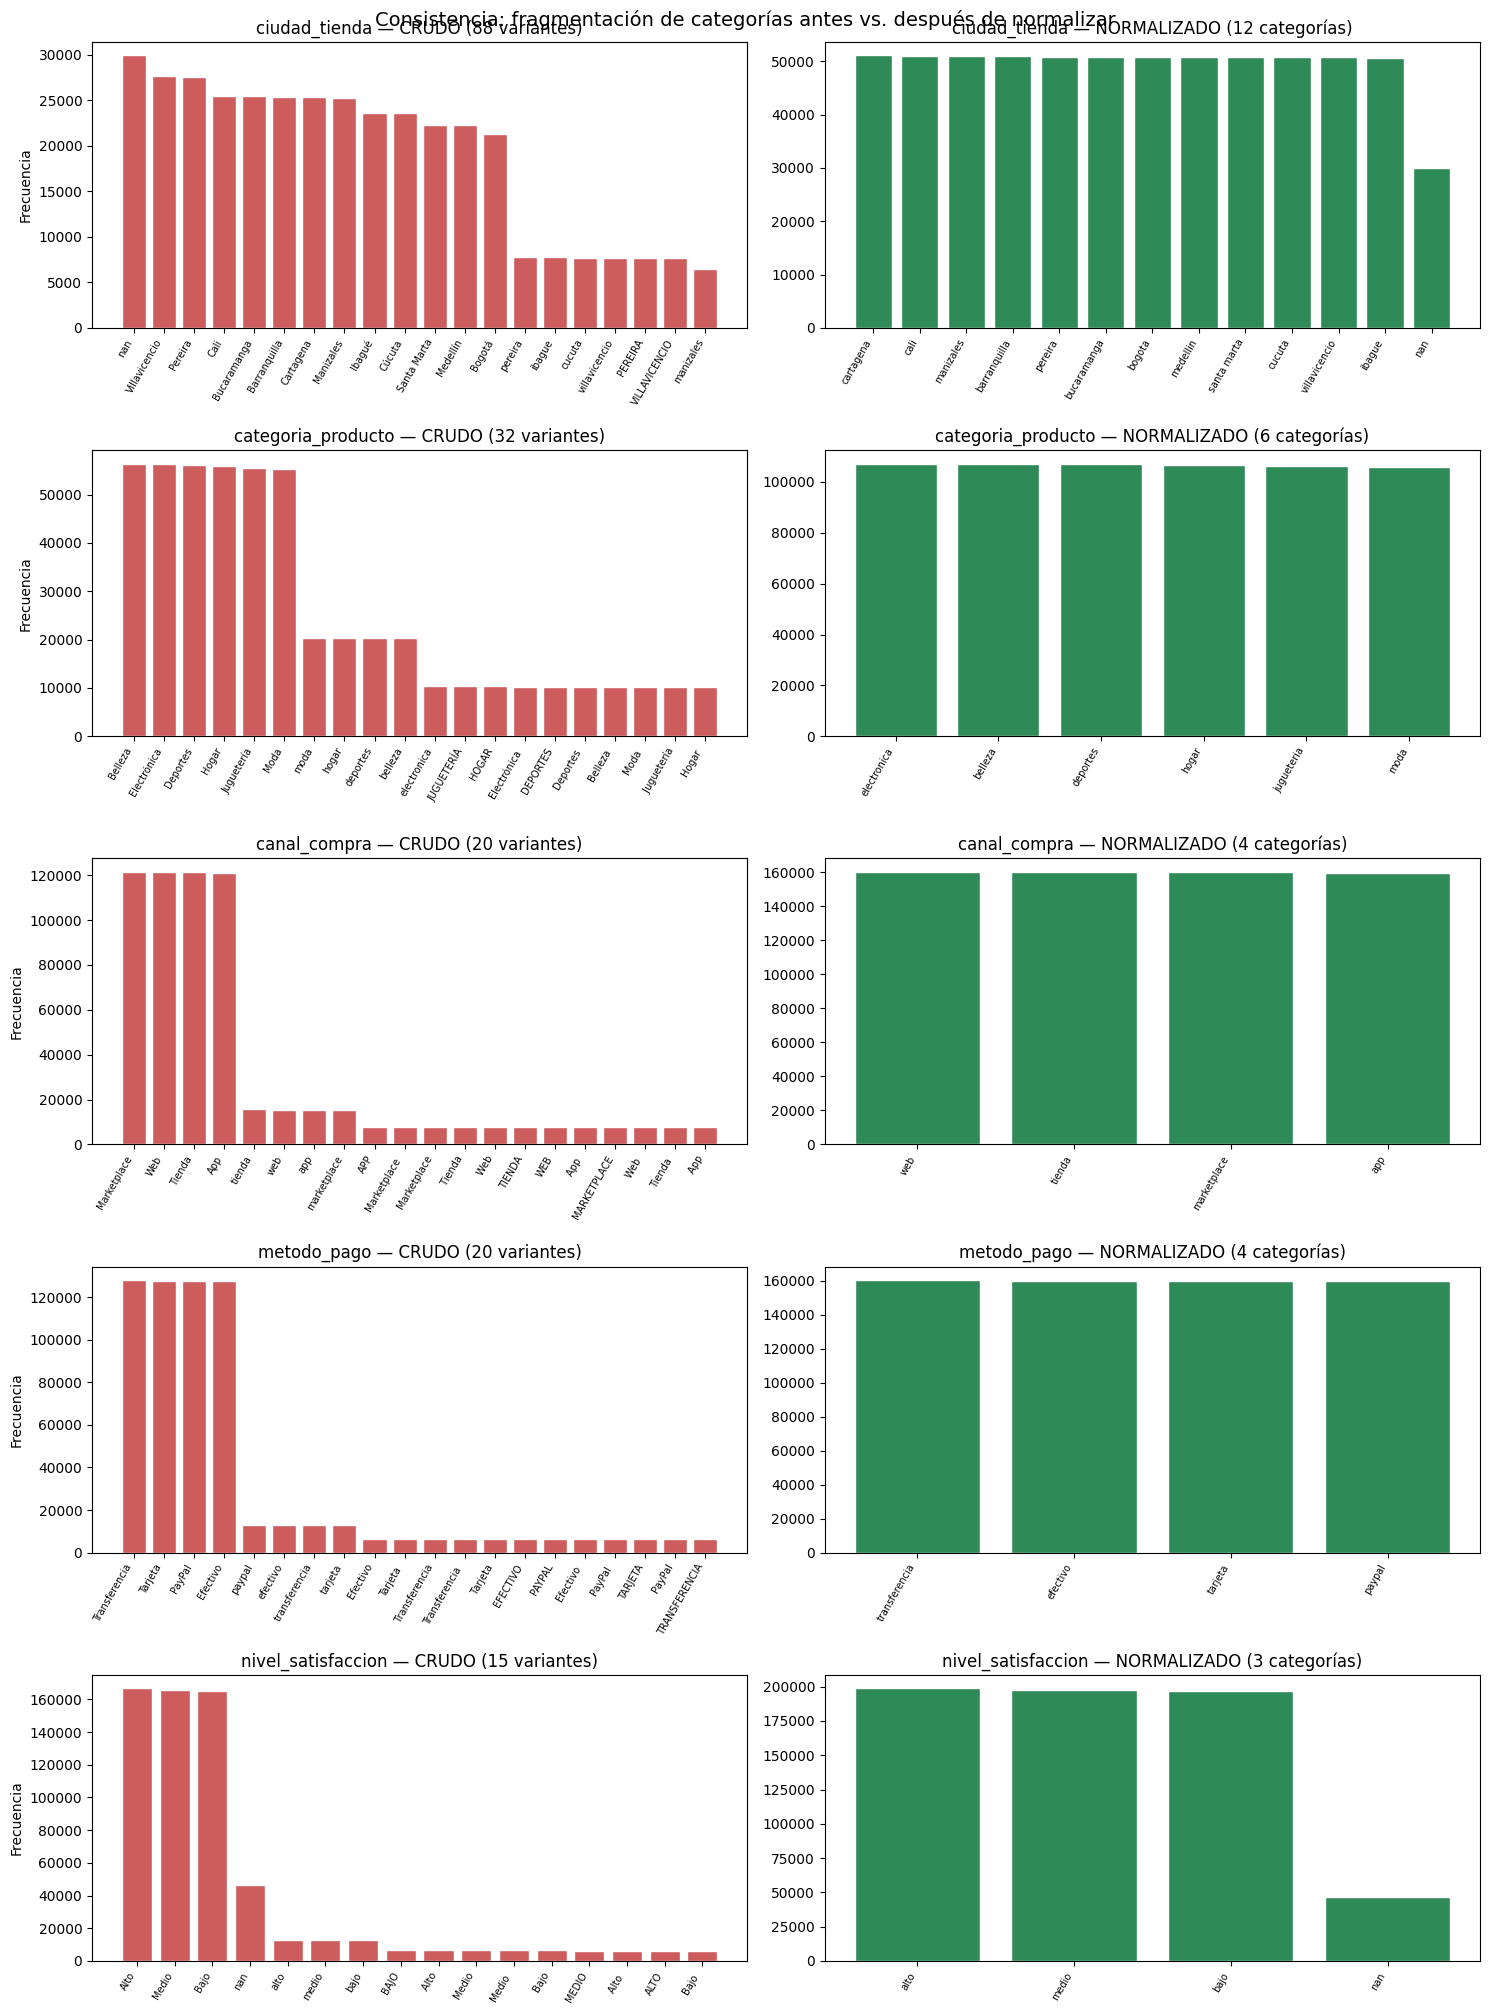

In [35]:
comparaciones = [
    ("ciudad_tienda",      df["ciudad_tienda"],      ciudad_norm),
    ("categoria_producto", df["categoria_producto"], cat_norm),
    ("canal_compra",       df["canal_compra"],       canal_norm),
    ("metodo_pago",        df["metodo_pago"],        pago_norm),
    ("nivel_satisfaccion", df["nivel_satisfaccion"], nivel_norm),
]

fig, axes = plt.subplots(len(comparaciones), 2, figsize=(15, 4.1 * len(comparaciones)))
for fila, (nombre, cruda, norm) in enumerate(comparaciones):
    vc_crudo = cruda.value_counts(dropna=False).head(20)
    vc_norm  = norm.value_counts(dropna=False).head(20)

    axes[fila, 0].bar(range(len(vc_crudo)), vc_crudo.values, color="indianred", edgecolor="white")
    axes[fila, 0].set_xticks(range(len(vc_crudo)))
    axes[fila, 0].set_xticklabels(vc_crudo.index.astype(str), rotation=60, ha="right", fontsize=7)
    axes[fila, 0].set_title(f"{nombre} — CRUDO ({cruda.nunique()} variantes)")
    axes[fila, 0].set_ylabel("Frecuencia")

    axes[fila, 1].bar(range(len(vc_norm)), vc_norm.values, color="seagreen", edgecolor="white")
    axes[fila, 1].set_xticks(range(len(vc_norm)))
    axes[fila, 1].set_xticklabels(vc_norm.index.astype(str), rotation=60, ha="right", fontsize=7)
    axes[fila, 1].set_title(f"{nombre} — NORMALIZADO ({norm.nunique()} categorías)")

plt.suptitle("Consistencia: fragmentación de categorías antes vs. después de normalizar", fontsize=14)
plt.tight_layout()
plt.show()

## Hallazgos de consistencia

Cinco columnas presentan el mismo concepto escrito de varias formas. La forma canónica se tomó como la variante más frecuente de cada grupo, y se cuentan como registros a ajustar todos los que no la usan.

| Columna afectada | Variantes crudas | Categorías reales | Registros a ajustar | % del dataset |
|---|---:|---:|---:|---:|
| `ciudad_tienda` | 88 | 12 | 314 864 | 49.20% |
| `categoria_producto` | 32 | 6 | 304 697 | 47.61% |
| `canal_compra` | 20 | 4 | 154 781 | 24.18% |
| `metodo_pago` | 20 | 4 | 129 372 | 20.21% |
| `nivel_satisfaccion` | 15 | 3 | 95 706 | 14.95% |
| `nivel_lealtad` | 4 | 4 | 0 | 0.00% |

**Grupos de variantes encontradas:**

- **`ciudad_tienda`** — el caso más severo, con tres tipos de variante a la vez:
  - *Tipográficas:* `Bogotá` / `bogota` / `BOGOTÁ` / `BOGOTA` / ` Bogotá` (espacio inicial)
  - *Contracciones y nombres largos:* `Bogota D.C.`, `BOGOTA DC`, `B/quilla`, `B/manga`, `Sta. Marta`, `SantaMarta`, `Santiago de Cali`, `Cartagena de Indias`, `Medellin, Ant.`, `Manizales, Caldas`
  - *Códigos de tres letras:* `BOG`, `MDE`, `BAQ`, `CTG`, `BGA`, `MZL`, `SMR`
  - Ejemplo del grupo Bogotá: `Bogotá` (21 305) + `bogota` (5 471) + `Bogota D.C.` (2 723) + `Bogota` (2 715) + `Bogotá ` (2 702) + `BOGOTA` (2 664) + ` Bogotá` (2 662) + `bogota d.c.` (2 654) + `BOGOTÁ` (2 646) + `BOGOTA DC` (2 638) + `BOG` (2 630) = **50 810 registros en una sola ciudad**
- **`categoria_producto`** — 32 variantes para 6 categorías: `Electrónica` / `electronica` / `ELECTRÓNICA` / `electrónica` / ` Electrónica` / `Electrónica ` , y el par sinónimo `Juguetería` / `jugueteria`
- **`canal_compra`** y **`metodo_pago`** — mismo patrón de mayúsculas y espacios sobrantes sobre 4 valores cada una
- **`nivel_satisfaccion`** — `Alto` / `alto` / `ALTO` / `Alto ` / ` Alto` sobre 3 niveles

**Nota metodológica.** `nivel_lealtad` llega limpia (4 variantes para 4 categorías, 0 registros a ajustar) y sirve como control: el método no marca inconsistencia donde no la hay, lo cual respalda las cifras de las otras cinco columnas.

### Validez

Se verifica que los valores cumplan el formato o la regla esperada: los identificadores contra su patrón, las fechas contra un formato reconocible, las variables numéricas contra su dominio admisible y las categóricas contra su lista cerrada de valores.

**Formato de identificadores.** En esta versión `id_pedido` usa seis dígitos (`P505195`) e `id_cliente` cinco o seis (`C45650`, `C164166`), a diferencia de los cinco y cuatro dígitos de la versión anterior.

In [36]:
patrones_id = {
    "id_pedido":  r"^P\d{6}$",
    "id_cliente": r"^C\d{5,6}$",
}

filas = []
for col, patron in patrones_id.items():
    valido = df[col].str.match(patron).fillna(False)
    filas.append({
        "Columna":            col,
        "Formatos Validos":   int(valido.sum()),
        "Formatos Invalidos": int((~valido).sum()),
        "% Falla":            f"{(~valido).sum() / n * 100:.2f}%",
    })

audit_id = pd.DataFrame(filas)
display(audit_id.style.hide(axis="index"))

Columna,Formatos Validos,Formatos Invalidos,% Falla
id_pedido,640000,0,0.00%
id_cliente,640000,0,0.00%


**Formato y rango de fechas.** `fecha_pedido` mezcla dos convenciones: ISO `aaaa-mm-dd` y barras `dd/mm/aaaa`. La convención de las fechas con barra queda **probada por los propios datos**: de las 434 008 fechas con barras, 258 070 tienen su primer componente mayor que 12 (por ejemplo `27/06/2025`) y **ninguna** tiene el segundo componente mayor que 12. Si el orden fuera mes/día, esas 258 070 filas serían meses inexistentes. Por eso el parseo se hace de forma híbrida y explícita —ISO estricto primero, `dd/mm/aaaa` después— en lugar de usar `format='mixed'`, que resuelve la ambigüedad a criterio de la librería y, además, «rescata» silenciosamente fechas imposibles como `2026-13-05`.

In [37]:
filas = []
for col, dt in [("fecha_pedido", df["fecha_pedido_dt"]),
                ("fecha_actualizacion_stock", df["fecha_stock_dt"])]:
    invalidas = int(dt.isna().sum())
    futuras   = int((dt > FECHA_CORTE).sum())
    filas.append({
        "Columna":             col,
        "Formatos Validos":    int(dt.notna().sum()),
        "Formatos Invalidos":  invalidas,
        "% Formato Invalido":  f"{invalidas / n * 100:.2f}%",
        "Fechas Futuras":      futuras,
        "% Futuras":           f"{futuras / n * 100:.2f}%",
    })

audit_fechas = pd.DataFrame(filas)
display(audit_fechas.style.hide(axis="index"))

# Evidencia de la convencion dia/mes
con_barra = df["fecha_pedido"].astype(str).str.match(r"^\d{1,2}/\d{1,2}/\d{4}$")
partes = df.loc[con_barra, "fecha_pedido"].str.split("/", expand=True).astype(int)
print(f"Fechas con barras: {con_barra.sum():,}")
print(f"  primer componente > 12 (solo puede ser dia): {(partes[0] > 12).sum():,}")
print(f"  segundo componente > 12 (seria mes imposible): {(partes[1] > 12).sum():,}")

# Que valores concretos fallan el parseo
malas = df.loc[df["fecha_pedido_dt"].isna(), "fecha_pedido"].value_counts()
print(f"\nValores de fecha_pedido no parseables ({malas.sum():,} registros):")
print(malas.to_string())

Columna,Formatos Validos,Formatos Invalidos,% Formato Invalido,Fechas Futuras,% Futuras
fecha_pedido,617313,22687,3.54%,16485,2.58%
fecha_actualizacion_stock,640000,0,0.00%,21722,3.39%


Fechas con barras: 434,008
  primer componente > 12 (solo puede ser dia): 258,070
  segundo componente > 12 (seria mes imposible): 0

Valores de fecha_pedido no parseables (22,687 registros):
fecha_pedido
00/00/0000    5698
31/04/2025    5688
30/02/2025    5675
2026-13-05    5626


**Formato de correo electrónico.**

In [38]:
col = "correo_cliente"
patron = r"^[^@\s]+@[^@\s]+\.[^@\s]+$"

valido    = df[col].str.match(patron).astype("boolean").fillna(False)
nulos     = int(df[col].isna().sum())
invalidos = int((~valido & df[col].notna()).sum())

audit_correo = pd.DataFrame([{
    "Columna":            col,
    "Formatos Validos":   int(valido.sum()),
    "Formatos Invalidos": invalidos,
    "Nulos":              nulos,
    "% Falla":            f"{invalidos / n * 100:.2f}%",
}])
display(audit_correo.style.hide(axis="index"))

print("Ejemplos de correos invalidos (falta la arroba):")
print(df.loc[~valido & df[col].notna(), col].head(5).to_string(index=False))

Columna,Formatos Validos,Formatos Invalidos,Nulos,% Falla
correo_cliente,483156,51532,105312,8.05%


Ejemplos de correos invalidos (falta la arroba):
cliente593809.hotmail.com
cliente583717.outlook.com
  cliente232336.gmail.com
  cliente184801.gmail.com
cliente427463.hotmail.com


**Dominio de las variables categóricas cerradas.** Se verifica que, una vez normalizada la escritura, cada columna solo tome valores de su lista admisible.

In [39]:
dominios = {
    "canal_compra":       {"web", "app", "tienda", "marketplace"},
    "metodo_pago":        {"efectivo", "tarjeta", "paypal", "transferencia"},
    "nivel_satisfaccion": {"bajo", "medio", "alto"},
    "nivel_lealtad":      {"bronce", "plata", "oro", "platino"},
    "fuga_cliente":       {"0", "1"},
}

filas = []
for col, admisibles in dominios.items():
    norm = df[col].map(base_texto)
    no_nulos = norm.notna()
    fuera = no_nulos & ~norm.isin(admisibles)
    filas.append({
        "Columna":            col,
        "Valores admisibles": ", ".join(sorted(admisibles)),
        "Fuera de dominio":   int(fuera.sum()),
        "% Falla":            f"{fuera.sum() / n * 100:.2f}%",
        "Valores hallados fuera": ", ".join(sorted(norm[fuera].unique())[:5]) or "—",
    })

audit_dominio = pd.DataFrame(filas)
display(audit_dominio.style.hide(axis="index"))

Columna,Valores admisibles,Fuera de dominio,% Falla,Valores hallados fuera
canal_compra,"app, marketplace, tienda, web",0,0.00%,—
metodo_pago,"efectivo, paypal, tarjeta, transferencia",0,0.00%,—
nivel_satisfaccion,"alto, bajo, medio",0,0.00%,—
nivel_lealtad,"bronce, oro, plata, platino",0,0.00%,—
fuga_cliente,"0, 1",0,0.00%,—


Ninguna columna categorica toma valores fuera de su dominio: el problema de estas
columnas no es de validez sino de consistencia de escritura (ver seccion siguiente).

## Hallazgos de validez

Se verificó que los valores cumplan el formato esperado, sin entrar todavía en si el contenido es correcto.

| Columna afectada | Comprobación | Registros inválidos | % del dataset |
|---|---|---:|---:|
| `correo_cliente` | debe contener `@` y un dominio con punto | 51 532 | 8.05% |
| `fecha_pedido` | debe convertirse a una fecha real | 22 687 | 3.54% |
| `fecha_pedido` | no debe ser posterior a la fecha de corte | 16 485 | 2.58% |
| `fecha_actualizacion_stock` | no debe ser posterior a la fecha de corte | 21 722 | 3.39% |
| `id_pedido` | patrón `P` + 6 dígitos | 0 | 0.00% |
| `id_cliente` | patrón `C` + 5 o 6 dígitos | 0 | 0.00% |
| `canal_compra`, `metodo_pago`, `nivel_satisfaccion`, `nivel_lealtad`, `fuga_cliente` | valor dentro de su dominio cerrado | 0 | 0.00% |

**Correos sin arroba (51 532).** Tienen la forma `cliente593809.hotmail.com`: el `@` fue reemplazado por un punto. El perfilado por firma de patrón lo confirma de forma independiente: de las siete formas distintas que toma la columna, dos carecen de arroba y suman exactamente 51 532 registros.

**Fechas no convertibles (22 687).** Son cuatro valores concretos, y conviene distinguirlos porque exigen tratamientos distintos:

| Valor | Registros | Qué es | Tratamiento |
|---|---:|---|---|
| `30/02/2025` | 5 675 | Día que no existe en febrero | Error de digitación: hay que recuperar la fecha real del origen |
| `31/04/2025` | 5 688 | Día que no existe en abril | Igual que el anterior |
| `2026-13-05` | 5 626 | Mes 13 | Igual que los anteriores |
| `00/00/0000` | 5 698 | Marcador de fecha ausente disfrazado de fecha | **No es un error de formato sino un dato faltante**, ya contabilizado en completitud |

Esta distinción importa: los tres primeros son 17 061 registros con una fecha equivocada que en principio existe en el sistema de origen, mientras que los 5 698 restantes son ausencias declaradas. Se cuentan aquí por su forma, pero en completitud se cuentan por su significado, y son los mismos registros.

**Sobre el método de conversión.** El parseo se hizo de forma híbrida y explícita (ISO estricto primero, `dd/mm/aaaa` después) en lugar de usar `format='mixed'`. La razón es doble. Primera, la convención día/mes queda **probada por los propios datos**: de las 434 008 fechas con barras, 258 070 tienen su primer componente mayor que 12 y **ninguna** tiene el segundo mayor que 12; si el orden fuera mes/día, esas 258 070 filas serían meses inexistentes. Segunda, `format='mixed'` «rescata» silenciosamente fechas imposibles como `2026-13-05` reinterpretándolas, lo cual las haría desaparecer del conteo de inválidas.

**Identificadores y dominios categóricos: sin problemas detectados.** Los patrones de `id_pedido` e `id_cliente` se cumplen en el 100% de los registros, y ninguna columna categórica toma valores fuera de su dominio. Eso no significa que el filtro esté mal escrito: significa que el problema de esas columnas es de consistencia de escritura, no de validez.

### Unicidad

Se verifican **dos criterios distintos**, y la diferencia entre ambos no es un detalle: determina cuál es la corrección correcta.

1. **`id_pedido` duplicado.** El identificador de pedido debe ser único por registro. Si se repite, hay un problema de integridad de la clave.
2. **Fila entera duplicada.** Si además del identificador **las 20 columnas son idénticas**, no se trata de dos pedidos distintos a los que se les asignó el mismo código, sino de la **misma fila cargada dos veces**.

El cruce entre los dos criterios es lo que da el diagnóstico:

| Situación | Qué significa | Cómo se corrige |
|---|---|---|
| Id repetido **y** fila idéntica | Carga duplicada del archivo | `drop_duplicates()`, sin pérdida de información |
| Id repetido **pero** fila distinta | Dos pedidos reales compartiendo código: la clave no es confiable | Hay que reasignar identificadores; no se puede borrar ninguna fila |
| Fila idéntica **pero** id no repetido | Imposible por construcción (el id forma parte de la fila) | — |

Por eso se calculan por separado y se mide explícitamente su intersección.

In [40]:
col = "id_pedido"

# Criterio 1: identificador de pedido repetido
dup_id_sobrantes = int(df[col].duplicated().sum())              # copias que sobran
dup_id_implicadas = int(df[col].duplicated(keep=False).sum())   # todas las filas involucradas
ids_repetidos     = int((df[col].value_counts() > 1).sum())     # identificadores distintos afectados

# Criterio 2: fila identica en las 20 columnas
dup_fila_sobrantes  = int(df.duplicated().sum())
dup_fila_implicadas = int(df.duplicated(keep=False).sum())

audit_unicidad = pd.DataFrame([
    {"Criterio": "1. id_pedido repetido",
     "Filas implicadas": dup_id_implicadas,
     "Copias sobrantes": dup_id_sobrantes,
     "% del total": f"{dup_id_sobrantes / n * 100:.2f}%"},
    {"Criterio": "2. Fila idéntica en las 20 columnas",
     "Filas implicadas": dup_fila_implicadas,
     "Copias sobrantes": dup_fila_sobrantes,
     "% del total": f"{dup_fila_sobrantes / n * 100:.2f}%"},
])
display(audit_unicidad.style.hide(axis="index"))

print(f"Identificadores distintos afectados: {ids_repetidos:,}")
print(f"Identificadores unicos en la base:   {df[col].nunique():,} de {n:,} registros")
print(f"Veces que se repite cada id afectado: "
      f"{df[col].value_counts()[df[col].value_counts() > 1].unique().tolist()}")

Criterio,Filas implicadas,Copias sobrantes,% del total
1. id_pedido repetido,40000,20000,3.12%
2. Fila idéntica en las 20 columnas,40000,20000,3.12%


Identificadores distintos afectados: 20,000
Identificadores unicos en la base:   620,000 de 640,000 registros


Veces que se repite cada id afectado: [2]


In [41]:
# Interseccion de los dos criterios: es lo que define el diagnostico
mascara_id   = df[col].duplicated(keep=False)
mascara_fila = df.duplicated(keep=False)

solo_id      = int((mascara_id & ~mascara_fila).sum())   # mismo codigo, contenido distinto
solo_fila    = int((mascara_fila & ~mascara_id).sum())   # imposible por construccion
ambos        = int((mascara_id &  mascara_fila).sum())

cruce_unicidad = pd.DataFrame([
    {"Caso": "Id repetido Y fila idéntica",  "Filas": ambos,
     "Diagnóstico": "Carga duplicada del archivo"},
    {"Caso": "Id repetido PERO fila distinta", "Filas": solo_id,
     "Diagnóstico": "Colisión real de clave (no hay)"},
    {"Caso": "Fila idéntica PERO id no repetido", "Filas": solo_fila,
     "Diagnóstico": "Imposible por construcción"},
])
display(cruce_unicidad.style.hide(axis="index"))

Caso,Filas,Diagnóstico
Id repetido Y fila idéntica,40000,Carga duplicada del archivo
Id repetido PERO fila distinta,0,Colisión real de clave (no hay)
Fila idéntica PERO id no repetido,0,Imposible por construcción


Los dos criterios coinciden EXACTAMENTE: las 40 000 filas implicadas en un id
repetido son las mismas 40 000 que forman pares identicos en las 20 columnas, y
cada id afectado aparece exactamente dos veces. No hay ni un solo caso de dos
pedidos distintos compartiendo codigo.

Diagnostico: carga duplicada del archivo, no reutilizacion de identificadores.
Correccion: drop_duplicates() elimina las 20 000 copias sobrantes sin riesgo de
perder informacion, porque las dos filas de cada par son indistinguibles.
Registros resultantes: 620,000

In [42]:
# Ejemplo concreto de un par duplicado, para dejar constancia de que son identicos
un_id = df.loc[df[col].duplicated(keep=False), col].iloc[0]
par = df[df[col] == un_id]
display(par)
print(f"Las {len(par)} filas del pedido {un_id} son identicas en las 20 columnas: "
      f"{par.drop_duplicates().shape[0] == 1}")

,id_pedido,id_cliente,fecha_pedido,canal_compra,metodo_pago,ciudad_tienda,codigo_postal,categoria_producto,producto,precio_unitario,...,edad_cliente,correo_cliente,nivel_satisfaccion,nivel_lealtad,comentario_cliente,peso_pedido_kg,fecha_actualizacion_stock,fuga_cliente,fecha_pedido_dt,fecha_stock_dt
4,P247920,C163018,01/05/2025,Web,Efectivo,Bucaramanga,6800112,Hogar,Juego de sábanas,222400.0,...,60,cliente147920@novamarket.com.co,Alto,Plata,NaN,12.3,2026-07-13,0,2025-05-01,2026-07-13
177451,P247920,C163018,01/05/2025,Web,Efectivo,Bucaramanga,6800112,Hogar,Juego de sábanas,222400.0,...,60,cliente147920@novamarket.com.co,Alto,Plata,NaN,12.3,2026-07-13,0,2025-05-01,2026-07-13


Las 2 filas del pedido P247920 son identicas en las 20 columnas: True


## Hallazgos de unicidad

Se verificaron **dos criterios distintos**, porque de su cruce depende cuál es la corrección correcta.

| Criterio | Filas implicadas | Copias sobrantes | % del dataset |
|---|---:|---:|---:|
| `id_pedido` repetido | 40 000 | 20 000 | 3.12% |
| Fila idéntica en las 20 columnas | 40 000 | 20 000 | 3.12% |

**Cruce de ambos criterios:**

| Caso | Filas | Diagnóstico |
|---|---:|---|
| Id repetido **y** fila idéntica | 40 000 | Carga duplicada del archivo |
| Id repetido **pero** fila distinta | 0 | No hay colisiones reales de clave |
| Fila idéntica **pero** id no repetido | 0 | Imposible por construcción |

**Diagnóstico.** Los dos criterios coinciden exactamente: las 40 000 filas implicadas en un identificador repetido son las mismas 40 000 que forman pares idénticos en las 20 columnas, y cada identificador afectado aparece **exactamente dos veces**. Se revisó un par a simple vista para confirmarlo: las dos filas son indistinguibles campo por campo.

No se trata entonces de dos pedidos distintos a los que se les asignó el mismo código —eso obligaría a reasignar identificadores sin poder borrar nada— sino de la **misma fila cargada dos veces**. La corrección es `drop_duplicates()`, que elimina las 20 000 copias sobrantes sin riesgo de perder información.

**Registros resultantes tras la deduplicación: 620 000**, que es exactamente el tamaño que menciona el enunciado del caso. El archivo entregado tiene 640 000 filas porque incluye las 20 000 duplicadas.

### Oportunidad

La oportunidad pregunta si el dato está **vigente y disponible a tiempo** para la decisión que debe apoyar. Se auditan cuatro criterios: dos de rango temporal, uno de vigencia del inventario y uno de coherencia entre las dos fechas del registro.

**El criterio de vigencia del inventario.** Una fecha de actualización de stock deja de ser útil pasado cierto plazo: si el último recuento de un artículo en una sede tiene más de **180 días**, el dato ya no describe la disponibilidad actual y cualquier decisión de reposición basada en él sería a ciegas. Ese es el umbral que se adopta como regla de negocio, y es un parámetro que conviene dejar explícito y modificable, puesto que depende de la rotación real del inventario y debería validarse con el área de logística.

In [43]:
UMBRAL_STOCK_DIAS = 180   # regla de negocio: mas alla de este plazo el stock se considera desactualizado

df["antiguedad_stock_dias"] = (FECHA_CORTE - df["fecha_stock_dt"]).dt.days
df["latencia_pedido_stock"] = (df["fecha_stock_dt"] - df["fecha_pedido_dt"]).dt.days

futuras_pedido = int((df["fecha_pedido_dt"] > FECHA_CORTE).sum())
futuras_stock  = int((df["fecha_stock_dt"]  > FECHA_CORTE).sum())
stock_viejo    = int((df["antiguedad_stock_dias"] > UMBRAL_STOCK_DIAS).sum())
stock_previo   = int((df["latencia_pedido_stock"] < 0).sum())

audit_temporalidad = pd.DataFrame([
    {"Criterio": f"fecha_pedido posterior al corte ({FECHA_CORTE.date()})",
     "Registros": futuras_pedido, "% del total": f"{futuras_pedido / n * 100:.2f}%"},
    {"Criterio": f"fecha_actualizacion_stock posterior al corte",
     "Registros": futuras_stock,  "% del total": f"{futuras_stock / n * 100:.2f}%"},
    {"Criterio": f"stock desactualizado (más de {UMBRAL_STOCK_DIAS} días)",
     "Registros": stock_viejo,    "% del total": f"{stock_viejo / n * 100:.2f}%"},
    {"Criterio": "fecha_actualizacion_stock anterior a fecha_pedido",
     "Registros": stock_previo,   "% del total": f"{stock_previo / n * 100:.2f}%"},
])
display(audit_temporalidad.style.hide(axis="index"))

print(f"Rango de fecha_pedido:              {df['fecha_pedido_dt'].min().date()}  ->  {df['fecha_pedido_dt'].max().date()}")
print(f"Rango de fecha_actualizacion_stock: {df['fecha_stock_dt'].min().date()}  ->  {df['fecha_stock_dt'].max().date()}")
print(f"Antiguedad mediana del stock: {df['antiguedad_stock_dias'].median():.0f} dias")

Criterio,Registros,% del total
fecha_pedido posterior al corte (2026-08-04),16485,2.58%
fecha_actualizacion_stock posterior al corte,21722,3.39%
stock desactualizado (más de 180 días),66069,10.32%
fecha_actualizacion_stock anterior a fecha_pedido,102835,16.07%


Rango de fecha_pedido:              2025-01-01  ->  2027-12-28
Rango de fecha_actualizacion_stock: 2023-01-01  ->  2027-12-28
Antiguedad mediana del stock: 93 dias


**La distribución de la antigüedad revela un problema estructural.** Al medir cuántos registros superan distintos umbrales aparece algo que no debería ocurrir en datos operativos reales.

In [44]:
tramos = [-600, -1, 0, 30, 90, 180, 365, 540, 730, 1400]
distribucion = (pd.cut(df["antiguedad_stock_dias"], tramos)
                  .value_counts().sort_index()
                  .rename_axis("antigüedad (días)").reset_index(name="registros"))
distribucion["%"] = (distribucion["registros"] / n * 100).round(2).astype(str) + "%"
display(distribucion.style.hide(axis="index"))

antigüedad (días),registros,%
"(-600, -1]",21722,3.39%
"(-1, 0]",0,0.0%
"(0, 30]",94174,14.71%
"(30, 90]",196503,30.7%
"(90, 180]",261532,40.86%
"(180, 365]",0,0.0%
"(365, 540]",0,0.0%
"(540, 730]",13491,2.11%
"(730, 1400]",52578,8.22%


El año 2025 NO APARECE: no existe ni un solo registro con fecha de stock en 2025,
pese a que si hay 32 983 en 2023, 33 086 en 2024 y 552 209 en 2026. Por eso los
umbrales de 180, 365 y 540 dias devuelven exactamente la misma cifra (66 069): entre
esos limites no cae ningun registro.

La ausencia total de registros en un año intermedio no corresponde a la operacion
continua de un inventario, donde las actualizaciones se reparten a lo largo del tiempo.
Los registros se agrupan en tres bloques separados: uno antiguo (2023-2024), uno
vigente (2026) y uno posterior a la fecha de corte (2027). Hay que consultar con el
area responsable si en 2025 hubo un cambio de sistema, una migracion o una carga
parcial, ya que eso explicaria el vacio y diria si esos datos son recuperables.

**¿Se puede inferir desde las transacciones si la fecha de stock es correcta?** La idea es sólida: si `fecha_actualizacion_stock` describiera de verdad el inventario de un artículo en una sede, entonces **todos los pedidos de ese artículo en esa sede realizados entre dos reposiciones deberían compartir la misma fecha de stock**. La fecha sería un atributo de la pareja (sede, producto) que cambia unas pocas veces al año, no un valor distinto en cada línea de pedido.

Eso es contrastable directamente: se agrupa por (sede, producto) y se cuenta cuántas fechas de stock distintas conviven dentro de cada grupo frente a cuántos pedidos tiene. Si la relación es de unas pocas fechas para muchos pedidos, el campo es real; si hay casi una fecha por pedido, el campo se generó a nivel de transacción.

In [45]:
trabajo = df.dropna(subset=["fecha_stock_dt"]).copy()
trabajo["sede"] = trabajo["codigo_postal"].astype("Int64").astype("string").str.zfill(7)
trabajo["producto_norm"] = trabajo["producto"].map(base_texto)

por_sede_producto = (trabajo.groupby(["sede", "producto_norm"])
    .agg(pedidos             =("fecha_stock_dt", "size"),
         fechas_stock_distintas=("fecha_stock_dt", "nunique"))
    .reset_index())
por_sede_producto = por_sede_producto[por_sede_producto["pedidos"] >= 2]
por_sede_producto["fechas_por_pedido"] = (
    por_sede_producto["fechas_stock_distintas"] / por_sede_producto["pedidos"]).round(3)

display(por_sede_producto.sort_values("pedidos", ascending=False).head(10)
        .style.hide(axis="index")
        .format({"pedidos": "{:,.0f}", "fechas_stock_distintas": "{:,.0f}",
                 "fechas_por_pedido": "{:.3f}"}))

print(f"Grupos (sede, producto) con 2 o mas pedidos: {len(por_sede_producto):,}")
print(f"Fechas de stock distintas por grupo -> mediana: {por_sede_producto['fechas_stock_distintas'].median():.0f}")
print(f"Razon fechas distintas / pedidos    -> mediana: {por_sede_producto['fechas_por_pedido'].median():.3f}")
print(f"Grupos con UNA sola fecha de stock: {int((por_sede_producto['fechas_stock_distintas'] == 1).sum()):,} "
      f"de {len(por_sede_producto):,}")

sede,producto_norm,pedidos,fechas_stock_distintas,fechas_por_pedido
5000101,camisa de lino,906,273,0.301
5000101,set de cuchillos,905,276,0.305
4700101,parlante bluetooth,900,279,0.310
5000101,secador de pelo,886,267,0.301
4700101,lampara de escritorio,883,265,0.300
5000101,bicicleta estatica,880,296,0.336
5000101,juego de sabanas,879,271,0.308
5000101,teclado mecanico,877,293,0.334
5000101,parlante bluetooth,875,276,0.315
5000101,kit de brochas,871,274,0.315


Grupos (sede, producto) con 2 o mas pedidos: 7,406
Fechas de stock distintas por grupo -> mediana: 30
Razon fechas distintas / pedidos    -> mediana: 0.889
Grupos con UNA sola fecha de stock: 37 de 7,406


La respuesta es negativa, y de forma concluyente: casi nueve de cada diez pedidos
traen una fecha de stock distinta a la de los demas pedidos del mismo articulo en la
misma sede. Solo 37 grupos de 7 406 comparten una unica fecha, y son precisamente los
que tienen muy pocos pedidos.

Conclusion: fecha_actualizacion_stock NO se puede validar contra las transacciones,
puesto que se comporta como un dato del pedido y no del inventario de la sede. Es el
mismo patron que aparece en precio_unitario y en peso_pedido_kg, es decir, columnas
cuyo nombre indica que describen una entidad (el articulo, el envio, el inventario)
pero cuyo contenido cambia en cada fila sin relacion con esa entidad.

**Latencia entre el pedido y la actualización de stock.** Complemento del análisis anterior: se mide la distancia en días entre ambas fechas del mismo registro.

In [46]:
latencia = df["latencia_pedido_stock"].dropna()

resumen_latencia = pd.DataFrame([
    {"Indicador": "Latencia mediana (días)",             "Valor": f"{latencia.median():.0f}"},
    {"Indicador": "Percentil 5 / percentil 95",          "Valor": f"{latencia.quantile(.05):.0f} / {latencia.quantile(.95):.0f}"},
    {"Indicador": "Stock anterior al pedido",            "Valor": f"{int((latencia < 0).sum()):,} ({(latencia < 0).sum()/n*100:.2f}%)"},
    {"Indicador": f"Stock anterior en más de {UMBRAL_STOCK_DIAS} días",
                                                          "Valor": f"{int((latencia < -UMBRAL_STOCK_DIAS).sum()):,} ({(latencia < -UMBRAL_STOCK_DIAS).sum()/n*100:.2f}%)"},
    {"Indicador": f"Separación mayor a {UMBRAL_STOCK_DIAS} días en cualquier sentido",
                                                          "Valor": f"{int((latencia.abs() > UMBRAL_STOCK_DIAS).sum()):,} ({(latencia.abs() > UMBRAL_STOCK_DIAS).sum()/n*100:.2f}%)"},
])
display(resumen_latencia.style.hide(axis="index"))

Indicador,Valor
Latencia mediana (días),217
Percentil 5 / percentil 95,-641 / 509
Stock anterior al pedido,"102,835 (16.07%)"
Stock anterior en más de 180 días,"75,206 (11.75%)"
Separación mayor a 180 días en cualquier sentido,"422,000 (65.94%)"


Que el stock se actualice ANTES del pedido no es imposible por si solo: el inventario
se refresca de forma independiente de las ventas. Lo que no tiene explicacion operativa
es la magnitud: dos tercios de los registros tienen las dos fechas separadas por mas de
medio año, y 75 206 pedidos se apoyan en un stock contado mas de 180 dias antes.

Impacto practico: ningun analisis de latencia de inventario, de rotacion ni de quiebre
de stock es viable con esta columna en su estado actual.

**Visualización distribución temporal.** Los histogramas muestran dónde se concentran las fechas, la cola posterior al corte y el hueco del año 2025 en la fecha de stock.

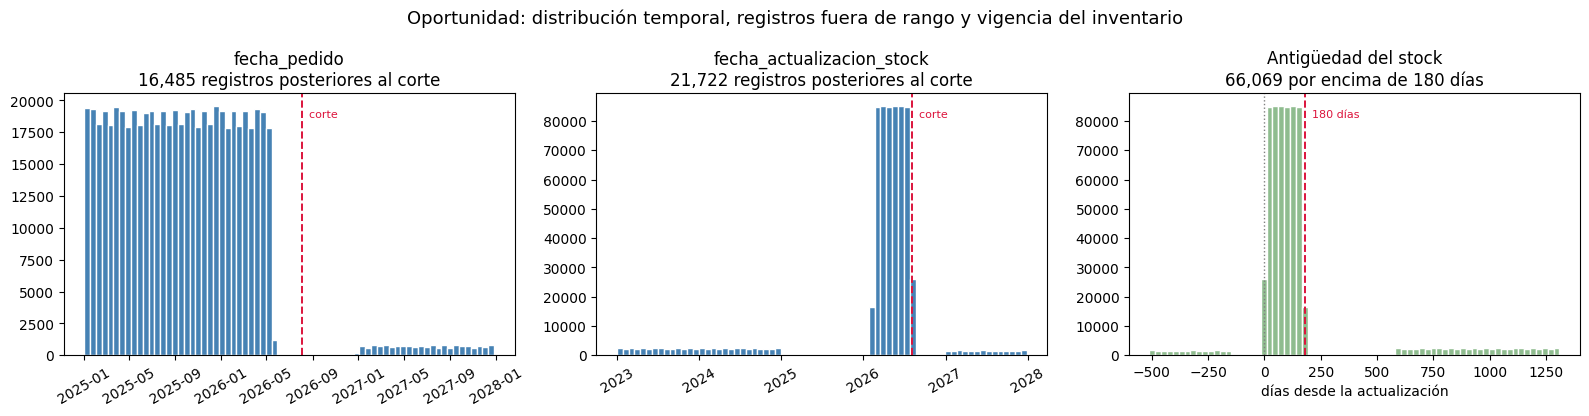

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

for ax, col, titulo in [(axes[0], "fecha_pedido_dt", "fecha_pedido"),
                        (axes[1], "fecha_stock_dt",  "fecha_actualizacion_stock")]:
    serie = df[col].dropna()
    ax.hist(serie, bins=70, color="steelblue", edgecolor="white")
    ax.axvline(FECHA_CORTE, color="crimson", linestyle="--", linewidth=1.4)
    ax.text(FECHA_CORTE, ax.get_ylim()[1] * 0.94, "  corte", color="crimson", fontsize=8, va="top")
    futuras = int((serie > FECHA_CORTE).sum())
    ax.set_title(f"{titulo}\n{futuras:,} registros posteriores al corte")
    ax.tick_params(axis="x", rotation=30)

ax = axes[2]
ant = df["antiguedad_stock_dias"].dropna()
ax.hist(ant, bins=70, color="darkseagreen", edgecolor="white")
ax.axvline(UMBRAL_STOCK_DIAS, color="crimson", linestyle="--", linewidth=1.4)
ax.text(UMBRAL_STOCK_DIAS, ax.get_ylim()[1] * 0.94, f"  {UMBRAL_STOCK_DIAS} días",
        color="crimson", fontsize=8, va="top")
ax.axvline(0, color="gray", linestyle=":", linewidth=1)
ax.set_title(f"Antigüedad del stock\n{stock_viejo:,} por encima de {UMBRAL_STOCK_DIAS} días")
ax.set_xlabel("días desde la actualización")

plt.suptitle("Oportunidad: distribución temporal, registros fuera de rango y vigencia del inventario",
             fontsize=13)
plt.tight_layout()
plt.show()

## Hallazgos de oportunidad

| Criterio | Registros | % del dataset |
|---|---:|---:|
| Separación mayor a 180 días entre `fecha_pedido` y `fecha_actualizacion_stock` | 422 000 | 65.94% |
| `fecha_actualizacion_stock` anterior a `fecha_pedido` | 102 835 | 16.07% |
| Stock desactualizado (más de 180 días desde el último recuento) | 66 069 | 10.32% |
| `fecha_actualizacion_stock` anterior al pedido en más de 180 días | 75 206 | 11.75% |
| `fecha_actualizacion_stock` posterior a la fecha de corte | 21 722 | 3.39% |
| `fecha_pedido` posterior a la fecha de corte | 16 485 | 2.58% |

**Justificación del umbral de 180 días.** Se adopta como regla de negocio que un recuento de inventario con más de seis meses de antigüedad ya no describe la disponibilidad actual, por lo que cualquier decisión de reposición basada en él sería a ciegas. El umbral se dejó como parámetro modificable en el código (`UMBRAL_STOCK_DIAS`) porque depende de la rotación real del inventario y debería validarse con el área de logística.

**Hallazgo estructural: falta el año 2025 completo.** Al medir la antigüedad se observó que los umbrales de 180, 365 y 540 días devuelven exactamente la misma cifra (66 069). La razón es que la columna no tiene ni un solo registro fechado en 2025:

| Año | Registros |
|---|---:|
| 2023 | 32 983 |
| 2024 | 33 086 |
| **2025** | **0** |
| 2026 | 552 209 |
| 2027 | 21 722 |

La ausencia total de registros en un año intermedio no corresponde a la operación continua de un inventario, donde las actualizaciones se reparten a lo largo del tiempo. Los registros se agrupan en tres bloques separados: uno antiguo (2023–2024), uno vigente (2026) y uno posterior a la fecha de corte (2027). Hay que consultar con el área responsable si en 2025 hubo un cambio de sistema, una migración o una carga parcial, puesto que eso explicaría el vacío y determinaría si los datos de ese periodo son recuperables.

**¿Se puede validar la fecha de stock contra las transacciones?** Si `fecha_actualizacion_stock` describiera el inventario de un artículo en una sede, todos los pedidos de ese artículo en esa sede realizados entre dos reposiciones deberían compartir la misma fecha. Se agrupó por (sede, producto) sobre los 7 406 grupos con dos o más pedidos y el resultado es de **0.89 fechas distintas por pedido**: casi cada pedido trae su propia fecha, y solo 37 grupos comparten una única fecha.

La conclusión es que **la fecha no se puede validar contra las transacciones, puesto que se comporta como un dato del pedido y no del inventario de la sede**. Es el mismo patrón que aparece en `precio_unitario` y `peso_pedido_kg`. Impacto práctico: con esta columna en su estado actual no es viable ningún análisis de latencia de inventario, rotación o quiebre de stock, y tampoco se puede reconstruir cuándo se actualizó realmente el stock de un artículo en una tienda.

### Cuantificación del alcance de los hallazgos no verificables

Tres hallazgos del catálogo no reportan un número de errores sino un **alcance**: la cantidad de registros que ya pasaron todas las reglas de dominio de su columna y que aun así no se pueden contrastar contra ninguna referencia. Como esa cifra sostiene tres filas del catálogo, se calcula aquí de forma explícita en lugar de deducirla a mano, y se verifica con `assert` que la partición cubre exactamente los 640 000 registros.

El criterio es el mismo en los tres casos: **alcance = total − registros que las reglas de dominio ya descartan**. Para `fecha_actualizacion_stock` el papel de «regla de dominio» lo cumple la única situación en que la fecha sí es verificable, que es cuando todos los pedidos de un artículo en una sede comparten una sola fecha.

In [48]:
# --- precio_unitario -----------------------------------------------------------
precio_nulo  = int(df["precio_unitario"].isna().sum())
precio_neg   = int((df["precio_unitario"] < 0).sum())
precio_alto  = int((df["precio_unitario"] > 10_000_000).sum())
precio_descartado = precio_nulo + precio_neg + precio_alto
alcance_precio    = n - precio_descartado

# Las tres reglas no se solapan (un nulo no es negativo, y negativo y >10M son
# excluyentes), asi que la particion es limpia y se puede verificar.
assert int(((df["precio_unitario"] < 0) & (df["precio_unitario"] > 10_000_000)).sum()) == 0
assert precio_descartado + alcance_precio == n

# --- peso_pedido_kg ------------------------------------------------------------
peso_descartado = int((df["peso_pedido_kg"] > 100).sum())
alcance_peso    = n - peso_descartado
assert peso_descartado + alcance_peso == n

# --- fecha_actualizacion_stock -------------------------------------------------
# Verificable = registros dentro de un grupo (sede, producto) con UNA sola fecha de
# stock. Incluye los grupos de un solo pedido, donde la unicidad es trivial.
grupos_stock = (trabajo.groupby(["sede", "producto_norm"])
                .agg(pedidos=("fecha_stock_dt", "size"),
                     fechas =("fecha_stock_dt", "nunique")))
stock_verificable = int(grupos_stock.loc[grupos_stock["fechas"] == 1, "pedidos"].sum())
alcance_stock     = n - stock_verificable
assert stock_verificable + alcance_stock == n

tabla_alcance = pd.DataFrame([
    {"Columna": "precio_unitario",
     "Descartado por reglas de dominio":
        f"{precio_nulo:,} sin dato + {precio_neg:,} negativos + {precio_alto:,} > 10 millones = {precio_descartado:,}",
     "Alcance (sin verificar)": alcance_precio,
     "% del total": alcance_precio / n * 100},
    {"Columna": "peso_pedido_kg",
     "Descartado por reglas de dominio": f"{peso_descartado:,} por encima de 100 kg",
     "Alcance (sin verificar)": alcance_peso,
     "% del total": alcance_peso / n * 100},
    {"Columna": "fecha_actualizacion_stock",
     "Descartado por reglas de dominio":
        f"{stock_verificable:,} verificables en grupos (sede, producto) con fecha unica",
     "Alcance (sin verificar)": alcance_stock,
     "% del total": alcance_stock / n * 100},
])
display(tabla_alcance.style.hide(axis="index")
        .format({"Alcance (sin verificar)": "{:,.0f}", "% del total": "{:.2f}%"}))

print(f"precio_unitario           : {precio_descartado:>7,} descartados + {alcance_precio:>7,} sin verificar = {n:,}")
print(f"peso_pedido_kg            : {peso_descartado:>7,} descartados + {alcance_peso:>7,} sin verificar = {n:,}")
print(f"fecha_actualizacion_stock : {stock_verificable:>7,} verificables + {alcance_stock:>7,} sin verificar = {n:,}")
print()
g1 = grupos_stock[(grupos_stock["fechas"] == 1) & (grupos_stock["pedidos"] >= 2)]
g2 = grupos_stock[grupos_stock["pedidos"] == 1]
print(f"Desglose de los {stock_verificable:,} verificables de la fecha de stock:")
print(f"  {len(g1):>4} grupos con 2 o mas pedidos y una sola fecha -> {int(g1['pedidos'].sum()):,} registros")
print(f"  {len(g2):>4} grupos de un solo pedido (unicidad trivial) -> {int(g2['pedidos'].sum()):,} registros")
print()
print("Verificacion OK: en las tres columnas la particion suma exactamente los 640 000 registros.")

Columna,Descartado por reglas de dominio,Alcance (sin verificar),% del total
precio_unitario,"21,640 sin dato + 19,629 negativos + 6,164 > 10 millones = 47,433","592,567",92.59%
peso_pedido_kg,"32,045 por encima de 100 kg","607,955",94.99%
fecha_actualizacion_stock,"995 verificables en grupos (sede, producto) con fecha unica","639,005",99.84%


precio_unitario           :  47,433 descartados + 592,567 sin verificar = 640,000
peso_pedido_kg            :  32,045 descartados + 607,955 sin verificar = 640,000
fecha_actualizacion_stock :     995 verificables + 639,005 sin verificar = 640,000

Desglose de los 995 verificables de la fecha de stock:
    37 grupos con 2 o mas pedidos y una sola fecha -> 74 registros
   921 grupos de un solo pedido (unicidad trivial) -> 921 registros

Verificacion OK: en las tres columnas la particion suma exactamente los 640 000 registros.


## 3. Catálogo de problemas

El catálogo reúne **38 problemas**: 31 de conteo puntual y 7 que afectan al uso de la columna completa. Es el mismo contenido, fila por fila, del archivo `S3_Grupo05_CatalogoProblemas.xlsx`.

Todas las cifras están calculadas sobre los **640 000 registros** del dataset y los porcentajes usan ese mismo denominador, de modo que son directamente comparables entre sí.

| # | Problema | Dimensión | Columnas afectadas | Nº registros | % | Impacto |
|---|---|---|---|---:|---:|---|
| 1 | Inconsistencia de escritura en `ciudad_tienda` (mayúsculas, tildes, espacios, abreviaturas `BOG`/`MDE`/`CTG`, nombres largos) | Consistencia | ciudad_tienda | 314 864 | 49.20% | Alto |
| 2 | Inconsistencia de escritura en `categoria_producto` | Consistencia | categoria_producto | 304 697 | 47.61% | Alto |
| 3 | Inconsistencia de escritura en `canal_compra` | Consistencia | canal_compra | 154 781 | 24.18% | Alto |
| 4 | Inconsistencia de escritura en `metodo_pago` | Consistencia | metodo_pago | 129 372 | 20.21% | Alto |
| 5 | Valores faltantes en `correo_cliente` | Completitud | correo_cliente | 105 312 | 16.46% | Bajo |
| 6 | `fecha_actualizacion_stock` anterior a `fecha_pedido` | Oportunidad | fecha_actualizacion_stock, fecha_pedido | 102 835 | 16.07% | Medio |
| 7 | Inconsistencia de escritura en `nivel_satisfaccion` | Consistencia | nivel_satisfaccion | 95 706 | 14.95% | Alto |
| 8 | Valores faltantes en `comentario_cliente` | Completitud | comentario_cliente | 90 806 | 14.19% | Bajo |
| 9 | Pedido y actualización de stock separados por más de 180 días | Oportunidad | fecha_pedido, fecha_actualizacion_stock | 422 000 | 65.94% | Medio |
| 10 | `fecha_actualizacion_stock` anterior al pedido en más de 180 días | Oportunidad | fecha_pedido, fecha_actualizacion_stock | 75 206 | 11.75% | Medio |
| 11 | Stock desactualizado (más de 180 días desde el último recuento) | Oportunidad | fecha_actualizacion_stock | 66 069 | 10.32% | Medio |
| 12 | Correos con formato inválido (sin arroba) | Validez | correo_cliente | 51 532 | 8.05% | Medio |
| 13 | Valores faltantes en `nivel_satisfaccion` | Completitud | nivel_satisfaccion | 46 469 | 7.26% | Medio |
| 14 | `monto_compra` ≤ 0 (arrastre aritmético de precio y unidades negativos) | Validez | monto_compra | 45 182 | 7.06% | Medio |
| 15 | Código postal no corresponde a la ciudad declarada (DIVIPOLA DANE) | Exactitud | ciudad_tienda, codigo_postal | 42 405 | 6.63% | Medio |
| 16 | Valores atípicos en `peso_pedido_kg` (más de 100 kg, hasta 1 399.9) | Validez | peso_pedido_kg | 32 045 | 5.01% | Medio |
| 17 | Valores faltantes en `ciudad_tienda` | Completitud | ciudad_tienda | 29 928 | 4.68% | Medio |
| 18 | `unidades_vendidas` ≤ 0 (negativas o cero) | Validez | unidades_vendidas | 27 877 | 4.36% | Medio |
| 19 | `edad_cliente` fuera de rango (negativa o mayor a 120) | Validez | edad_cliente | 27 829 | 4.35% | Medio |
| 20 | Formato de fecha no reconocible en `fecha_pedido` (`30/02/2025`, `31/04/2025`, `2026-13-05`, `00/00/0000`) | Validez | fecha_pedido | 22 687 | 3.54% | Medio |
| 21 | `fecha_actualizacion_stock` posterior a la fecha de corte | Oportunidad | fecha_actualizacion_stock | 21 722 | 3.39% | Bajo |
| 22 | Valores faltantes en `precio_unitario` | Completitud | precio_unitario | 21 640 | 3.38% | Medio |
| 23 | Valores faltantes en `monto_compra` | Completitud | monto_compra | 21 640 | 3.38% | Medio |
| 24 | `id_pedido` duplicado y fila idéntica en las 20 columnas (carga duplicada) | Unicidad | todas | 20 000 | 3.12% | Medio |
| 25 | `precio_unitario` negativo | Validez | precio_unitario | 19 629 | 3.07% | Medio |
| 26 | `unidades_vendidas` con valores atípicos extremos (5 000 y 9 999) | Validez | unidades_vendidas | 18 526 | 2.89% | Medio |
| 27 | `fecha_pedido` posterior a la fecha de corte | Oportunidad | fecha_pedido | 16 485 | 2.58% | Alto |
| 28 | `monto_compra` con valores atípicos extremos (más de 1 000 millones) | Validez | monto_compra | 16 158 | 2.52% | Medio |
| 29 | `precio_unitario` superior a $10.000.000 (máximo de $999.000.000, idéntico en los 24 productos) | Validez | precio_unitario | 6 164 | 0.96% | Medio |
| 30 | Valores faltantes en `fecha_pedido` registrados como `00/00/0000` | Completitud | fecha_pedido | 5 698 | 0.89% | Medio |
| 31 | `precio_unitario` con valores atípicos extremos (más de 100 millones) | Validez | precio_unitario | 3 050 | 0.48% | Medio |

**Hallazgos que afectan al uso de la columna completa.** Los siguientes no son valores puntuales equivocados sino columnas que no se pueden validar contra la entidad que dicen describir. El alcance se reporta como el número de registros sobre los que la verificación queda sin resolver, es decir, los que pasan las reglas de dominio pero que no se pueden contrastar contra ninguna referencia. Se listan aparte para no mezclarlos con los conteos de errores puntuales de la tabla anterior.

| # | Problema | Dimensión | Columnas afectadas | Evidencia |
|---|---|---|---|---|
| 32 | `edad_cliente` varía dentro de un mismo cliente más de lo que permite la ventana temporal del archivo | Exactitud | edad_cliente, id_cliente | Los pedidos cubren 3 años, de modo que nadie puede envejecer más de 3; el rango mediano dentro de un mismo cliente es de 40 años y el 97.9% de los clientes supera el tope. **Alcance: 622 458 registros (97.26%)** |
| 33 | `fuga_cliente` alterna de forma repetida dentro del mismo cliente | Exactitud | fuga_cliente, id_cliente | 45 298 clientes entran y salen de la condición de fuga dos o más veces, con un máximo de 8 alternancias, sobre una mediana de 4 pedidos por cliente. **Alcance: 259 564 registros (40.56%)** |
| 34 | `correo_cliente` se deriva del `id_pedido` (menos 100 000), no del cliente | Exactitud | correo_cliente | 100% de los 534 688 registros con correo; ninguno coincide con el `id_cliente` |
| 35 | `precio_unitario` no se puede validar contra el `producto` | Exactitud | precio_unitario, producto | η² = 0.000026; ninguno de los 120 grupos (producto, cantidad) tiene precio único. **Alcance: 592 567 registros (92.59%)** que pasan las reglas de dominio pero quedan sin verificar |
| 36 | `peso_pedido_kg` no se puede validar contra el producto ni la cantidad | Exactitud | peso_pedido_kg, producto, unidades_vendidas | η² = 0.000046; correlación peso-cantidad de −0.0009. **Alcance: 607 955 registros (94.99%)** |
| 37 | `fecha_actualizacion_stock` se comporta como dato del pedido y no del inventario de la sede | Oportunidad / Exactitud | fecha_actualizacion_stock | 0.89 fechas distintas por pedido dentro de cada (sede, producto); solo 37 de 7 406 grupos con fecha única. **Alcance: 639 005 registros (99.84%)** |
| 38 | Ausencia total de registros del año 2025 en `fecha_actualizacion_stock` | Oportunidad | fecha_actualizacion_stock | 32 983 registros en 2023, 33 086 en 2024, **0 en 2025**, 552 209 en 2026 y 21 722 en 2027. A confirmar con el área responsable si hubo cambio de sistema o migración |

**Por qué `precio_unitario` aparece varias veces en el catálogo.** Puede parecer una contradicción decir que el precio no se puede validar y al mismo tiempo reportar errores concretos de precio. No lo es, puesto que se trata de dos comprobaciones distintas:

- **Reglas de dominio.** Son absolutas y no necesitan ninguna referencia: un precio de venta no puede ser negativo y ningún artículo de este surtido cuesta más de diez millones de pesos. Eso se puede afirmar sin saber cuál es el precio correcto de cada producto.
- **Validación contra referencia.** Es relativa y sí la necesita: para decir si $305.600 es el precio correcto de un *Rompecabezas 1000 piezas* hace falta una referencia por artículo, y esa referencia no existe en el archivo ni se puede reconstruir desde él.

El «alcance» que se reporta en esta tabla es exactamente **el complemento de las reglas de dominio**: los registros que ya pasaron todos los filtros absolutos y que aun así quedan sin poder verificar. Por eso las cifras cierran de forma exacta contra el total:

| Columna | Descartados por reglas de dominio | Sin verificar (alcance) | Total |
|---|---:|---:|---:|
| `precio_unitario` | 21 640 sin dato + 19 629 negativos + 6 164 por encima de 10 millones = **47 433** | **592 567** | 640 000 |
| `peso_pedido_kg` | 32 045 por encima de 100 kg | **607 955** | 640 000 |
| `fecha_actualizacion_stock` | 995 verificables (74 en los 37 grupos con fecha única y 921 en grupos de un solo pedido) | **639 005** | 640 000 |

La lectura práctica es que los 47 433 registros de precio que sí se detectan son **la parte pequeña del problema**. El resto, el 92,59% de la columna, no se puede dar por bueno ni por malo, y esa incertidumbre es en sí misma el hallazgo que hay que reportar al área responsable.

**Criterio de impacto.** *Alto*: afecta a una porción amplia de registros y/o compromete análisis centrales (segmentación geográfica, series temporales, agregados de satisfacción). *Medio*: afecta variables usadas en cálculos pero en proporción moderada, o corregible con reglas claras. *Bajo*: baja proporción y/o sin efecto directo sobre métricas de negocio.

**Nota sobre solapamientos.** Los problemas del catálogo no son mutuamente excluyentes y sus conteos no deben sumarse. Cuatro relaciones concretas conviene tener presentes:

1. Los 45 182 `monto_compra` ≤ 0 (fila 14) son consecuencia aritmética de los 19 629 precios negativos (fila 25) y las 27 877 unidades ≤ 0 (fila 18). La verificación de coherencia demostró que el monto siempre es el producto exacto de ambos, así que corregir el origen corrige el derivado.
2. Los 21 640 faltantes de `monto_compra` (fila 23) coinciden exactamente con los de `precio_unitario` (fila 22), por la misma razón.
3. Los 5 698 `00/00/0000` de `fecha_pedido` aparecen dos veces: como faltantes (fila 30) y dentro de los 22 687 formatos no reconocibles (fila 20). Son el mismo dato visto desde dos dimensiones.
4. Los 29 928 faltantes de `ciudad_tienda` (fila 17) están excluidos del cálculo de exactitud (fila 15), precisamente para no contar el mismo registro en dos dimensiones.

### Resumen ejecutivo del diagnóstico

| Dimensión | Alcance de la revisión | Registro más afectado |
|---|---|---|
| Consistencia | 6 columnas revisadas, 5 fragmentadas | `ciudad_tienda`, con 88 variantes crudas para 12 ciudades reales (314 864 registros a ajustar, 49.20%) |
| Completitud | 20 columnas medidas, 7 con vacíos | `correo_cliente`, con 105 312 vacíos (16.46%) |
| Validez | 7 comprobaciones, 4 con hallazgos | `correo_cliente` sin arroba, con 51 532 (8.05%) |
| Oportunidad | 4 criterios temporales | Separación pedido-stock mayor a 180 días, con 422 000 (65.94%) |
| Exactitud | 9 reglas auditadas, 6 incumplidas | 5 columnas que no describen lo que su nombre declara |
| Unicidad | 2 criterios cruzados | 20 000 filas duplicadas completas (3.12%) |

**Prioridad de corrección sugerida.** El orden que maximiza recuperación de datos por esfuerzo invertido es: (1) normalizar las cinco columnas categóricas, que con un diccionario de equivalencias recupera casi la mitad de la base; (2) eliminar las 20 000 filas duplicadas, que es una sola instrucción sin pérdida de información; (3) imputar `ciudad_tienda` desde `codigo_postal`, que es determinista; (4) unificar el parseo de fechas y decidir el tratamiento de las 22 687 no parseables, separando las 17 061 mal digitadas de las 5 698 ausentes; y (5) tratar los valores numéricos imposibles, que exigen reglas de negocio y por tanto consulta con el área responsable.

**Lo que la auditoría no puede resolver.** Siete hallazgos no se corrigen con limpieza porque el dato correcto no está en el archivo: la incoherencia de la edad frente a la ventana temporal, la alternancia de la condición de fuga, el origen transaccional del correo, la falta de relación entre precio y producto y entre peso y producto o cantidad, el comportamiento de la fecha de stock y el vacío del año 2025. Los siete se escalan al área que genera el archivo.

**Un hallazgo descartado a propósito.** `nivel_lealtad` toma varios valores dentro de un mismo cliente, pero eso es el comportamiento esperado de un segmento comercial y no un defecto, por lo que se excluyó del catálogo. Se deja constancia porque descartar un falso hallazgo también es resultado de la auditoría.